# EDA: Cruce SECOP-DANE | 2018–2024
Análisis exploratorio sobre el **Gold Mart** del pipeline de Desarrollo Social y Económico.

**Fuentes integradas:**
- **SECOP I & II** — Contratos públicos municipales (Colombia Compra Eficiente)
- **CNPV 2018** — Censo Nacional de Población y Vivienda (NBI, IPM, etnia)
- **EMICRON** — Encuesta de Micronegocios DANE (economía popular)
- **Proyecciones DANE** — Población municipal 2018–2024

**Granularidad:** Municipio × Año (2018–2024) | Capa: Gold Mart


## 0. Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Detección robusta de la raíz del proyecto ──────────────────────
_here = Path().resolve()
ROOT = _here
for _candidate in [_here, _here.parent, _here.parent.parent]:
    if (_candidate / 'data' / 'gold' / 'marts' / 'latest').exists():
        ROOT = _candidate
        break

MART_PATH    = ROOT / 'data' / 'gold' / 'marts' / 'latest' / 'mart_desarrollo_social_economico_municipio_anio.parquet'
SPRINT2_PATH = ROOT / 'data' / 'cruce_secop_dane_sprint2.parquet'
ETNIA_PATH   = ROOT / 'data' / 'etnia_checkpoint.parquet'

# ── Constantes ─────────────────────────────────────────────────────
AÑOS          = list(range(2018, 2025))
COL_AÑO       = 'anio_key'
COL_NBI       = 'nbi_pct'
COL_IPM       = 'ipm_total'
COL_MONTO     = 'inversion_total_monto'
COL_CONTRATOS = 'cantidad_procesos_adjudicados'
COL_DIVIPOLA  = 'divipola_key'
COL_MUNICIPIO = 'nombre_municipio_referencia'
COL_DEPTO     = 'nombre_departamento'

# ── Estilo ─────────────────────────────────────────────────────────
plt.style.use('ggplot')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'font.size': 10})
PALETA_AÑOS = plt.cm.tab10(np.linspace(0, 0.9, len(AÑOS)))
COLOR_MAP   = dict(zip(AÑOS, PALETA_AÑOS))

def fmt_moneda(x, pos=None):
    if pd.isna(x): return 'N/A'
    if x >= 1e12: return f'${x/1e12:.1f}T'
    if x >= 1e9:  return f'${x/1e9:.1f}B'
    if x >= 1e6:  return f'${x/1e6:.1f}M'
    if x >= 1e3:  return f'${x/1e3:.0f}K'
    return f'${x:,.0f}'

def gini(array):
    a = np.array(array, dtype=np.float64)
    a = np.sort(a[a >= 0])
    if len(a) == 0 or a.sum() == 0: return np.nan
    n = len(a)
    return (n + 1 - 2 * np.sum(np.cumsum(a)) / a.sum()) / n

print(f'Raiz del proyecto : {ROOT}')
print(f'Anos de analisis  : {AÑOS}')
print(f'Mart existe       : {MART_PATH.exists()}')


Raiz del proyecto : C:\Users\user\Documents\001 Uni\Octavo\CONSULTORIA\Desarrollo social y economico\desarrollo_social_y_economico
Anos de analisis  : [2018, 2019, 2020, 2021, 2022, 2023, 2024]
Mart existe       : True


## 1. Carga e inspección inicial

Partimos del **Gold Mart** (salida del pipeline) y lo enriquecemos con las variables
de vulnerabilidad social (NBI, IPM, etnia) provenientes del CNPV 2018.
Estas variables son un snapshot fijo del censo y se propagan a todos los años.

In [2]:
# ── 1. Gold Mart (temporal: municipio × año) ───────────────────────
mart = pd.read_parquet(MART_PATH)
mart[COL_AÑO] = pd.to_numeric(mart[COL_AÑO], errors='coerce').astype('Int64')
mart = mart[mart[COL_AÑO].isin(AÑOS)].copy()
mart[COL_DIVIPOLA] = mart[COL_DIVIPOLA].astype(str).str.strip().str.zfill(5)

# ── 2. Vulnerabilidad social (CNPV 2018 via Sprint 2) ──────────────
try:
    sprint2 = pd.read_parquet(SPRINT2_PATH)
    sprint2['divipola_key'] = sprint2['divipola_municipio'].astype(str).str.strip().str.zfill(5)
except:
    print("ADVERTENCIA: No se pudo cargar Sprint2")
    sprint2 = pd.DataFrame(columns=["divipola_municipio", "divipola_key", "nbi", "miseria", "ipm_total"])

# Detecta la columna NBI independientemente del encoding del parquet
_nbi_col = next((c for c in sprint2.columns
                 if 'nbi' in c.lower() and not c.endswith('.1') and not c.endswith('.2')), None)
_mis_col = next((c for c in sprint2.columns
                 if 'miseria' in c.lower() and not c.endswith('.1') and not c.endswith('.2')), None)
_ipm_col = 'ipm_total' if 'ipm_total' in sprint2.columns else None

_vuln_map = {}
if _nbi_col: _vuln_map[_nbi_col] = COL_NBI
if _mis_col: _vuln_map[_mis_col] = 'miseria_pct'
if _ipm_col: _vuln_map[_ipm_col] = COL_IPM

sprint2_vuln = sprint2[['divipola_key'] + list(_vuln_map.keys())].rename(columns=_vuln_map).copy()
for c in [COL_NBI, 'miseria_pct', COL_IPM]:
    if c in sprint2_vuln.columns:
        sprint2_vuln[c] = pd.to_numeric(sprint2_vuln[c], errors='coerce')

# ── 3. Etnia (CNPV 2018) ───────────────────────────────────────────
try:
    etnia = pd.read_parquet(ETNIA_PATH)
    etnia['divipola_key'] = etnia['divipola_municipio'].astype(str).str.strip().str.zfill(5)
except:
    print("ADVERTENCIA: No se pudo cargar Etnia")
    etnia = pd.DataFrame(columns=["divipola_municipio", "divipola_key"])
_etnia_cols = ['divipola_key'] + [c for c in etnia.columns
                                   if c.startswith('etnia_') and '_pct' in c]
etnia_sub = etnia[[c for c in _etnia_cols if c in etnia.columns]]

# ── 4. Enriquecimiento del Mart ─────────────────────────────────────
df = (mart
      .merge(sprint2_vuln, on='divipola_key', how='left')
      .merge(etnia_sub,    on='divipola_key', how='left'))

# Solo municipios (excluir agregados departamentales XX000)
df_mun = df[~df['divipola_key'].str.endswith('000')].copy()

# Tipos numéricos
_num_cols = [COL_MONTO, COL_CONTRATOS, 'proveedores_unicos',
             'poblacion_total_proyectada', 'poblacion_censo_2018',
             'volumen_micronegocios_exp', COL_NBI, 'miseria_pct', COL_IPM,
             'indicador_inversion_per_capita', 'etnia_indigena_pct', 'etnia_afro_pct']
for col in _num_cols:
    if col in df_mun.columns:
        df_mun[col] = pd.to_numeric(df_mun[col], errors='coerce')

print('=' * 65)
print('INSPECCION INICIAL — Gold Mart + Vulnerabilidad CNPV 2018')
print('=' * 65)
print(f'Dimensiones totales     : {df.shape[0]:,} x {df.shape[1]}')
print(f'Solo municipios         : {df_mun.shape[0]:,} x {df_mun.shape[1]}')
print('\nRegistros por año (solo municipios):')
print(df_mun[COL_AÑO].value_counts().sort_index().to_string())
print(f'\nMunicipios únicos  : {df_mun[COL_DIVIPOLA].nunique():,}')
print(f'Departamentos      : {df_mun[COL_DEPTO].nunique():,}')
print(f'Regiones           : {sorted(df_mun["region"].dropna().unique())}')
print('\nNulos en variables clave:')
for c in [COL_NBI, COL_IPM, COL_MONTO, COL_CONTRATOS,
          'poblacion_total_proyectada', 'volumen_micronegocios_exp']:
    if c in df_mun.columns:
        n = df_mun[c].isna().sum()
        print(f'  {c}: {n:,} ({n/len(df_mun)*100:.1f}%)')
display(df_mun.head(3))


ADVERTENCIA: No se pudo cargar Sprint2
ADVERTENCIA: No se pudo cargar Etnia
INSPECCION INICIAL — Gold Mart + Vulnerabilidad CNPV 2018
Dimensiones totales     : 8,085 x 25
Solo municipios         : 7,854 x 25

Registros por año (solo municipios):
anio_key
2018    1122
2019    1122
2020    1122
2021    1122
2022    1122
2023    1122
2024    1122

Municipios únicos  : 1,122
Departamentos      : 33
Regiones           : ['Amazonia', 'Andina', 'Bogotá D.C.', 'Caribe', 'Llanos', 'Pacífico']

Nulos en variables clave:
  nbi_pct: 7,854 (100.0%)
  ipm_total: 7,854 (100.0%)
  inversion_total_monto: 0 (0.0%)
  cantidad_procesos_adjudicados: 0 (0.0%)
  poblacion_total_proyectada: 0 (0.0%)
  volumen_micronegocios_exp: 0 (0.0%)


,divipola_key,anio_key,nombre_municipio_referencia,nombre_departamento,divipola_departamento,region,categoria_municipio,fuente_nombre,es_anio_electoral_presidencial,es_anio_electoral_regional,...,poblacion_total_proyectada,poblacion_censo_2018,indicador_inversion_per_capita,indicador_densidad_micronegocios,tiene_componente_social,tiene_componente_economico,_mart_generation_timestamp,nbi_pct,miseria_pct,ipm_total
0,05001,2018,Medellín,Antioquia,05,Andina,Especial,catalogo_divipola_oficial,True,False,...,0.0,2372330.0,3.735940e+06,0.0,True,True,2026-05-07T19:12:05.428396,NaN,NaN,NaN
1,05001,2019,Medellín,Antioquia,05,Andina,Especial,catalogo_divipola_oficial,False,True,...,0.0,2372330.0,4.117077e+06,0.0,True,True,2026-05-07T19:12:05.428396,NaN,NaN,NaN
2,05001,2020,Medellín,Antioquia,05,Andina,Especial,catalogo_divipola_oficial,False,False,...,0.0,2372330.0,5.726901e+06,0.0,True,True,2026-05-07T19:12:05.428396,NaN,NaN,NaN


## 2. Evolución temporal de la contratación (2018–2024)

Resumen anual:


,monto_total,num_contratos,proveedores,municipios_activos,monto_promedio,var_monto_pct
anio_key,,,,,,
2018,1.047465e+14,1090983.0,611089.0,1122,9.335697e+10,NaN
2019,1.380134e+14,1193513.0,666718.0,1122,1.230066e+11,31.759386
2020,1.094466e+14,1134462.0,622284.0,1122,9.754595e+10,-20.698581
2021,1.485243e+14,1292400.0,696621.0,1122,1.323746e+11,35.704818
2022,1.748349e+14,1099821.0,669542.0,1122,1.558243e+11,17.714709
2023,1.257925e+14,969726.0,580116.0,1122,1.121145e+11,-28.050719
2024,1.143712e+14,963955.0,590591.0,1122,1.019352e+11,-9.079409


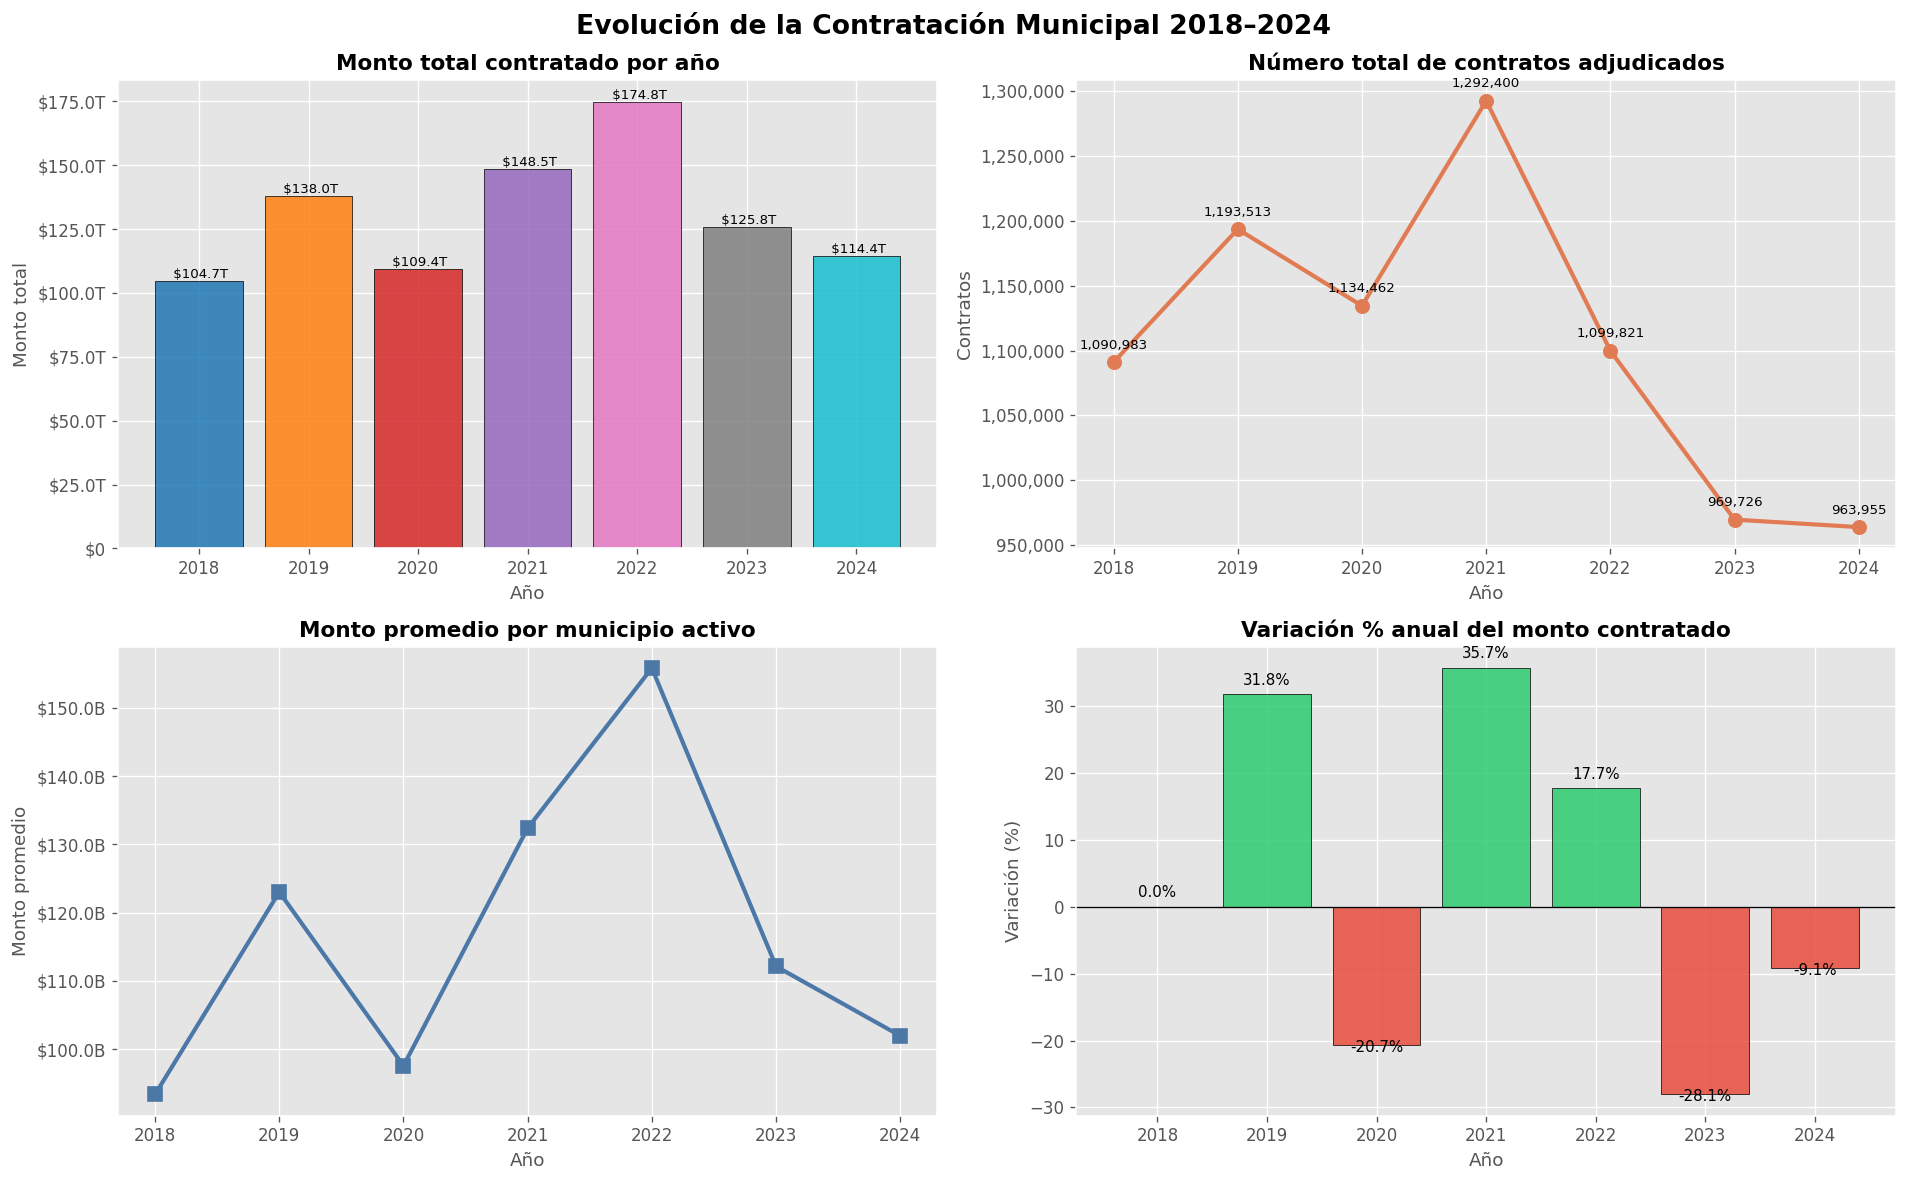

In [3]:
evol = df_mun.groupby(COL_AÑO).agg(
    monto_total        = (COL_MONTO,     'sum'),
    num_contratos      = (COL_CONTRATOS,  'sum'),
    proveedores        = ('proveedores_unicos', 'sum'),
    municipios_activos = (COL_DIVIPOLA,   'nunique'),
).reset_index()
evol['monto_promedio'] = evol['monto_total'] / evol['municipios_activos']
evol['var_monto_pct']  = evol['monto_total'].pct_change() * 100
evol[COL_AÑO] = evol[COL_AÑO].astype(int)

print('Resumen anual:')
display(evol.set_index(COL_AÑO))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Evolución de la Contratación Municipal 2018–2024',
             fontsize=16, fontweight='bold')

ax = axes[0, 0]
bars = ax.bar(evol[COL_AÑO], evol['monto_total'],
              color=[COLOR_MAP[a] for a in evol[COL_AÑO]],
              edgecolor='black', alpha=0.85)
ax.yaxis.set_major_formatter(FuncFormatter(fmt_moneda))
ax.set_title('Monto total contratado por año', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Monto total')
for bar, val in zip(bars, evol['monto_total']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f' {fmt_moneda(val)}', ha='center', va='bottom', fontsize=8)

ax = axes[0, 1]
ax.plot(evol[COL_AÑO], evol['num_contratos'],
        marker='o', linewidth=2.5, color='#E07B54', markersize=8)
ax.set_title('Número total de contratos adjudicados', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Contratos')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
for x, y in zip(evol[COL_AÑO], evol['num_contratos']):
    ax.annotate(f'{y:,.0f}', (x, y), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8)

ax = axes[1, 0]
ax.plot(evol[COL_AÑO], evol['monto_promedio'],
        marker='s', linewidth=2.5, color='#4C78A8', markersize=8)
ax.yaxis.set_major_formatter(FuncFormatter(fmt_moneda))
ax.set_title('Monto promedio por municipio activo', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Monto promedio')

ax = axes[1, 1]
colores_var = ['#E74C3C' if v < 0 else '#2ECC71'
               for v in evol['var_monto_pct'].fillna(0)]
ax.bar(evol[COL_AÑO], evol['var_monto_pct'].fillna(0),
       color=colores_var, edgecolor='black', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Variación % anual del monto contratado', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Variación (%)')
for x, v in zip(evol[COL_AÑO], evol['var_monto_pct'].fillna(0)):
    ax.text(x, v + (1 if v >= 0 else -1.5), f'{v:.1f}%',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()


## 3. Distribución de la inversión por año

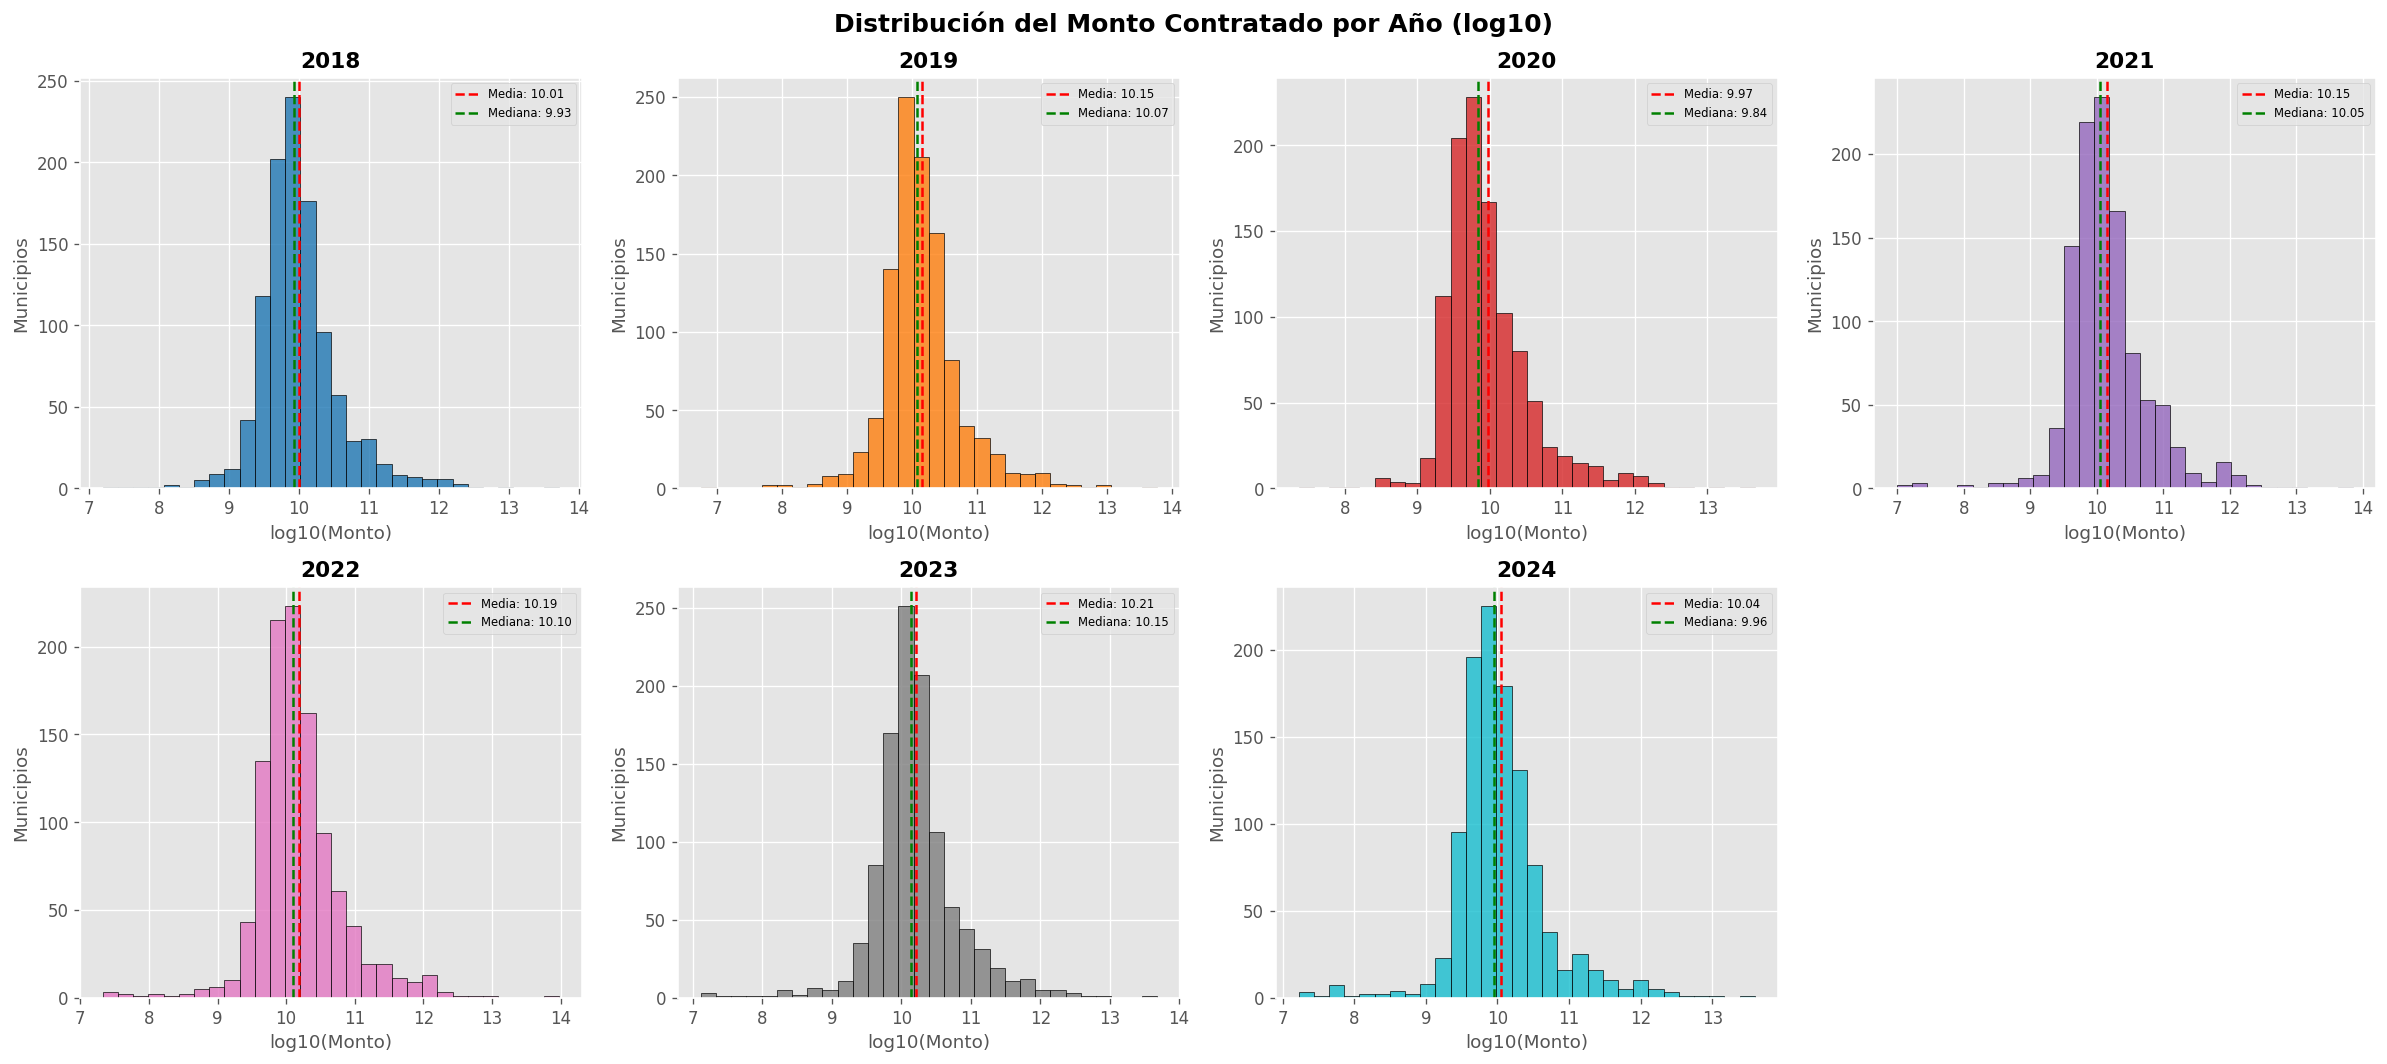


Estadísticas del monto contratado por año:


,count,mean,std,min,25%,50%,75%,90%,95%,max
anio_key,,,,,,,,,,
2018,1122.0,9.335697e+10,1.598873e+12,0.0,4.444827e+09,7.935712e+09,1.615266e+10,4.541681e+10,1.213158e+11,5.253275e+13
2019,1122.0,1.230066e+11,1.825095e+12,0.0,6.160846e+09,1.123499e+10,2.529488e+10,6.579916e+10,1.706020e+11,5.881999e+13
2020,1122.0,9.754595e+10,1.423952e+12,0.0,3.639605e+09,6.598501e+09,1.490057e+10,4.852251e+10,1.303023e+11,4.514610e+13
2021,1122.0,1.323746e+11,2.141409e+12,0.0,5.786564e+09,1.080330e+10,2.269137e+10,7.834990e+10,1.747726e+11,7.010682e+13
2022,1122.0,1.558243e+11,2.859235e+12,0.0,6.314132e+09,1.223316e+10,2.661430e+10,7.789534e+10,2.153921e+11,9.499126e+13
2023,1122.0,1.121145e+11,1.475527e+12,0.0,7.093097e+09,1.336681e+10,2.646913e+10,8.704957e+10,1.882671e+11,4.778948e+13
2024,1122.0,1.019352e+11,1.252412e+12,0.0,4.621488e+09,8.780961e+09,1.890183e+10,5.097874e+10,1.559606e+11,3.903394e+13


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharey=False)
fig.suptitle('Distribución del Monto Contratado por Año (log10)',
             fontsize=15, fontweight='bold')

for idx, año in enumerate(AÑOS):
    ax = axes[idx // 4][idx % 4]
    sub = df_mun[(df_mun[COL_AÑO] == año) & (df_mun[COL_MONTO] > 0)].copy()
    sub['log_monto'] = np.log10(sub[COL_MONTO])
    ax.hist(sub['log_monto'], bins=30, color=COLOR_MAP[año], edgecolor='black', alpha=0.8)
    ax.axvline(sub['log_monto'].mean(),   color='red',   linestyle='--', lw=1.5,
               label=f'Media: {sub["log_monto"].mean():.2f}')
    ax.axvline(sub['log_monto'].median(), color='green', linestyle='--', lw=1.5,
               label=f'Mediana: {sub["log_monto"].median():.2f}')
    ax.set_title(str(año), fontweight='bold')
    ax.set_xlabel('log10(Monto)'); ax.set_ylabel('Municipios')
    ax.legend(fontsize=7)

axes[1][3].set_visible(False)
plt.tight_layout(); plt.show()

print('\nEstadísticas del monto contratado por año:')
display(df_mun.groupby(COL_AÑO)[COL_MONTO].describe(percentiles=[.25, .5, .75, .9, .95]))


## 4. Distribución de vulnerabilidad social (NBI e IPM)

> **Nota metodológica:** NBI e IPM provienen del CNPV 2018 (censo fijo). Se visualizan por año para mostrar con qué municipios se cruza cada corte temporal, pero el valor del indicador no varía entre años.

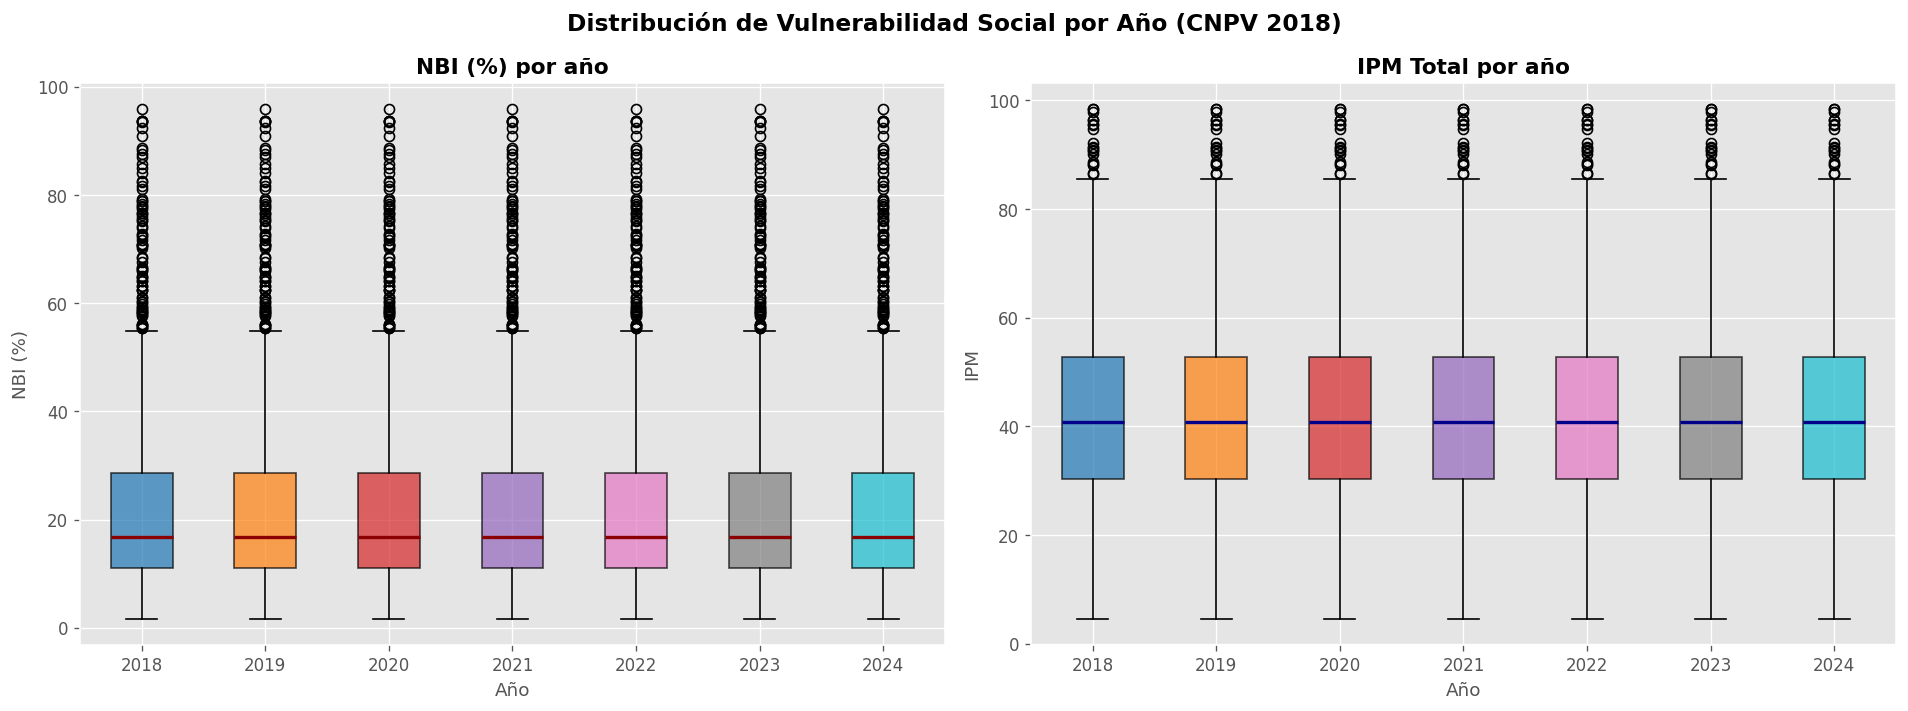


NBI promedio por año:


,mean,median,std
anio_key,,,
2018,22.93,16.76,17.76
2019,22.93,16.76,17.76
2020,22.93,16.76,17.76
2021,22.93,16.76,17.76
2022,22.93,16.76,17.76
2023,22.93,16.76,17.76
2024,22.93,16.76,17.76



IPM promedio por año:


,mean,median,std
anio_key,,,
2018,41.79,40.8,17.35
2019,41.79,40.8,17.35
2020,41.79,40.8,17.35
2021,41.79,40.8,17.35
2022,41.79,40.8,17.35
2023,41.79,40.8,17.35
2024,41.79,40.8,17.35


In [5]:
if COL_NBI not in df_mun.columns or df_mun[COL_NBI].isna().all():
    print('ADVERTENCIA: variable NBI no disponible — revisar datos/cruce_secop_dane_sprint2.parquet')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Distribución de Vulnerabilidad Social por Año (CNPV 2018)',
                 fontsize=14, fontweight='bold')

    ax = axes[0]
    datos_nbi = [df_mun.loc[df_mun[COL_AÑO] == a, COL_NBI].dropna().values for a in AÑOS]
    bp = ax.boxplot(datos_nbi, labels=AÑOS, patch_artist=True,
                    medianprops=dict(color='darkred', linewidth=2))
    for patch, color in zip(bp['boxes'], PALETA_AÑOS):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title('NBI (%) por año', fontweight='bold')
    ax.set_xlabel('Año'); ax.set_ylabel('NBI (%)')

    ax = axes[1]
    if COL_IPM in df_mun.columns:
        datos_ipm = [df_mun.loc[df_mun[COL_AÑO] == a, COL_IPM].dropna().values for a in AÑOS]
        bp2 = ax.boxplot(datos_ipm, labels=AÑOS, patch_artist=True,
                         medianprops=dict(color='darkblue', linewidth=2))
        for patch, color in zip(bp2['boxes'], PALETA_AÑOS):
            patch.set_facecolor(color); patch.set_alpha(0.7)
        ax.set_title('IPM Total por año', fontweight='bold')
        ax.set_xlabel('Año'); ax.set_ylabel('IPM')
    else:
        ax.text(0.5, 0.5, 'IPM no disponible', ha='center', va='center',
                transform=ax.transAxes, fontsize=14)
    plt.tight_layout(); plt.show()

    print('\nNBI promedio por año:')
    display(df_mun.groupby(COL_AÑO)[COL_NBI].agg(['mean','median','std']).round(2))
    if COL_IPM in df_mun.columns:
        print('\nIPM promedio por año:')
        display(df_mun.groupby(COL_AÑO)[COL_IPM].agg(['mean','median','std']).round(2))


## 5. Concentración de la inversión — Top 15 municipios por año

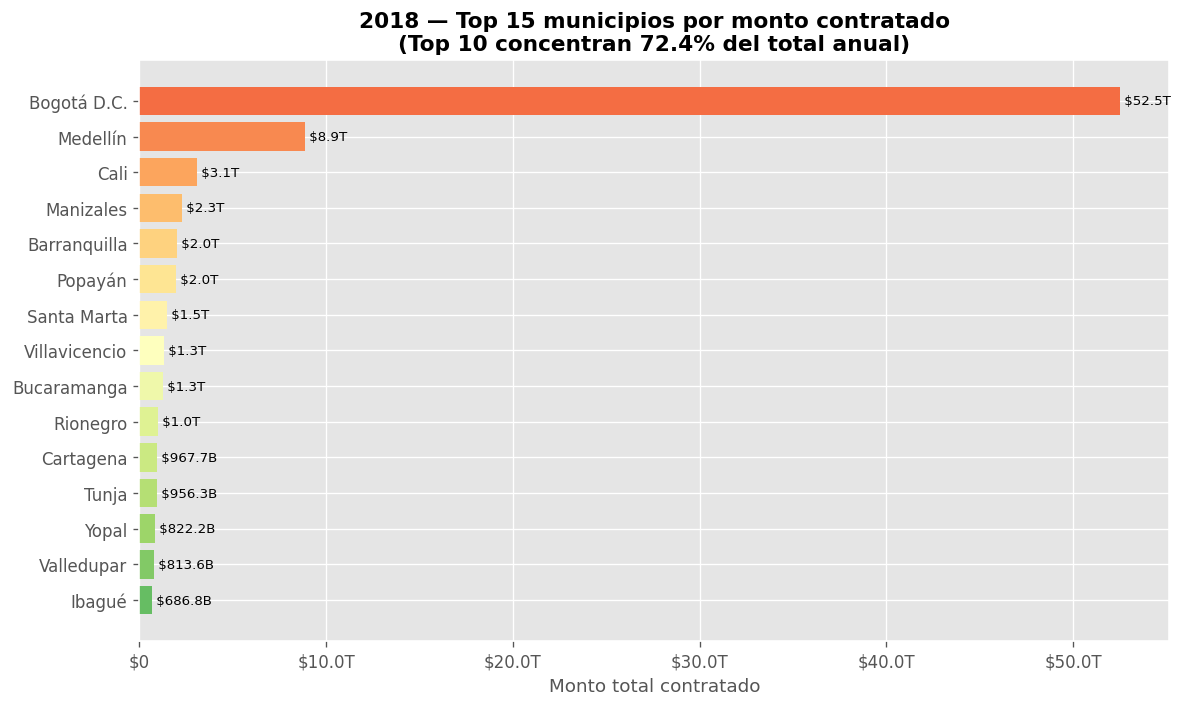

  Monto total 2018: $104.7T


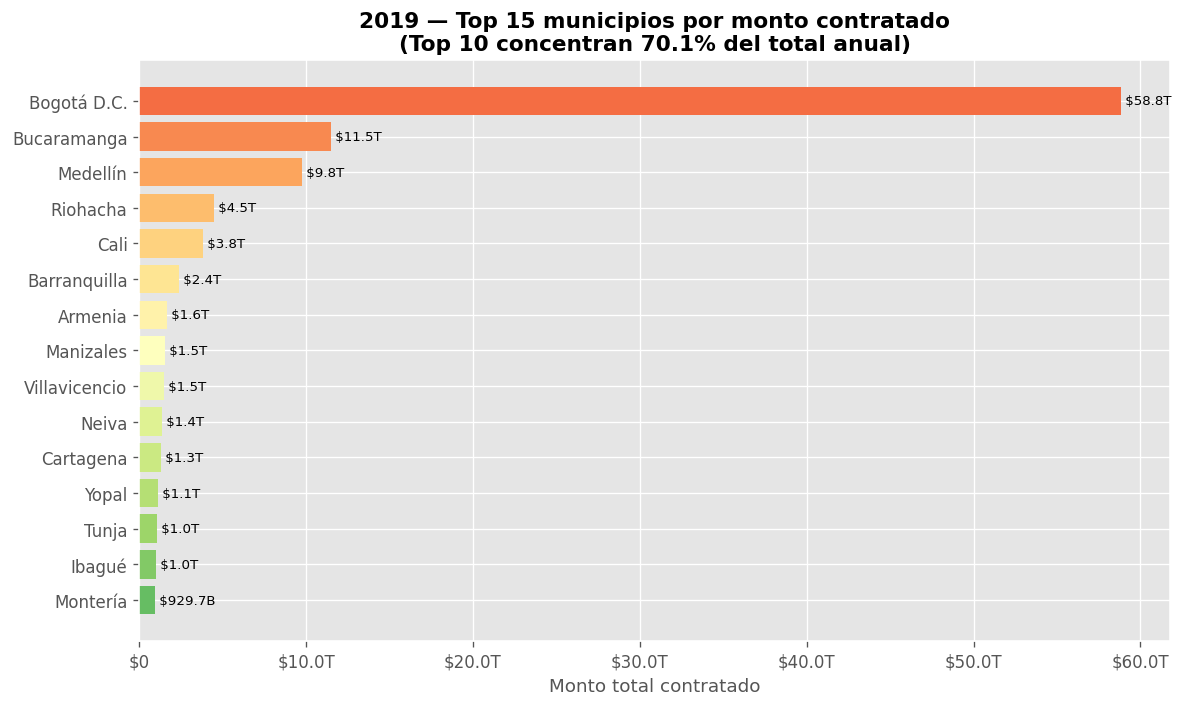

  Monto total 2019: $138.0T


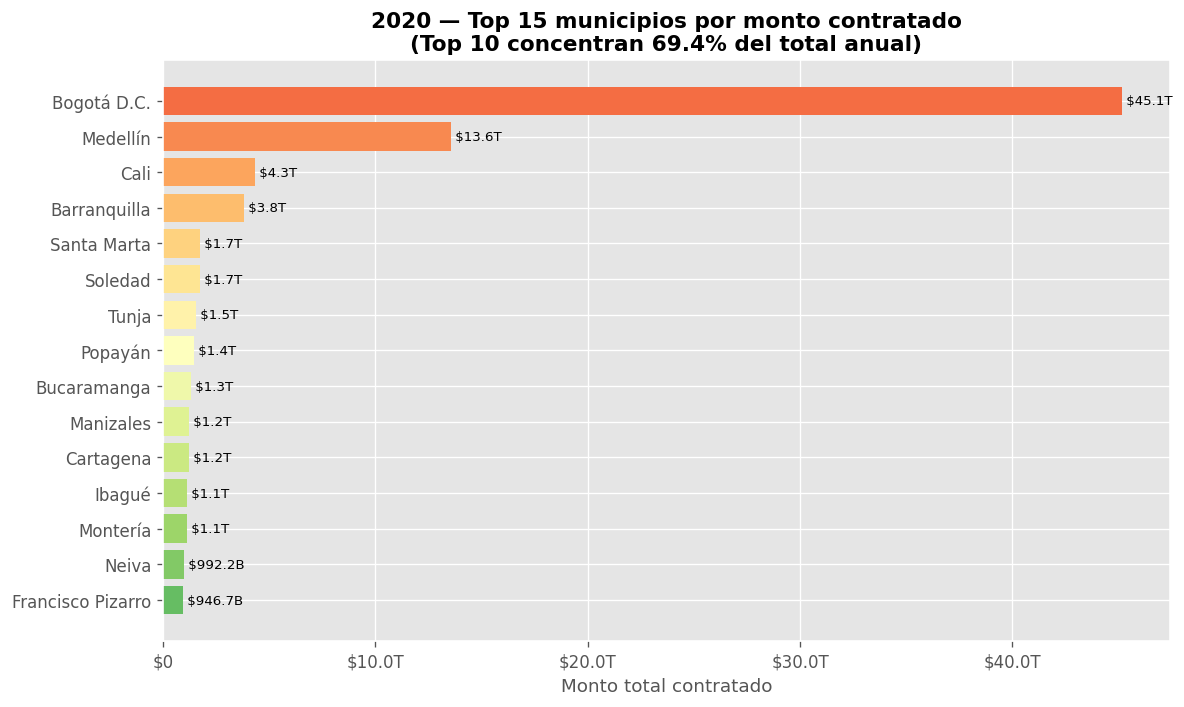

  Monto total 2020: $109.4T


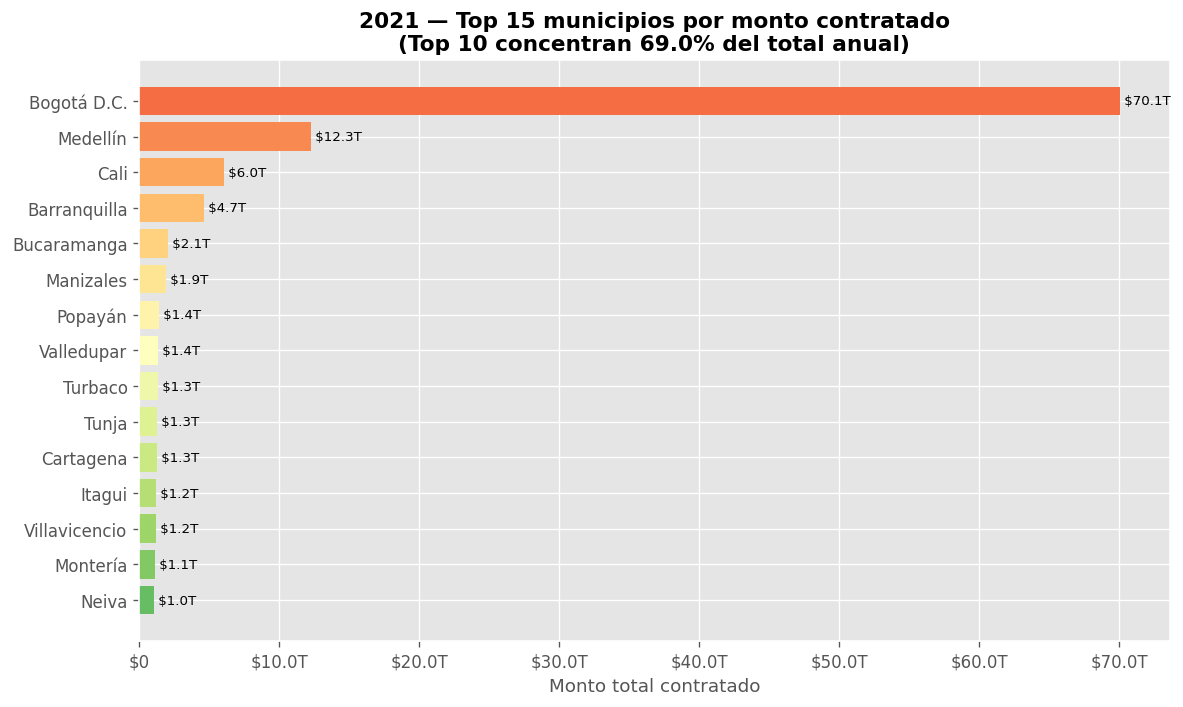

  Monto total 2021: $148.5T


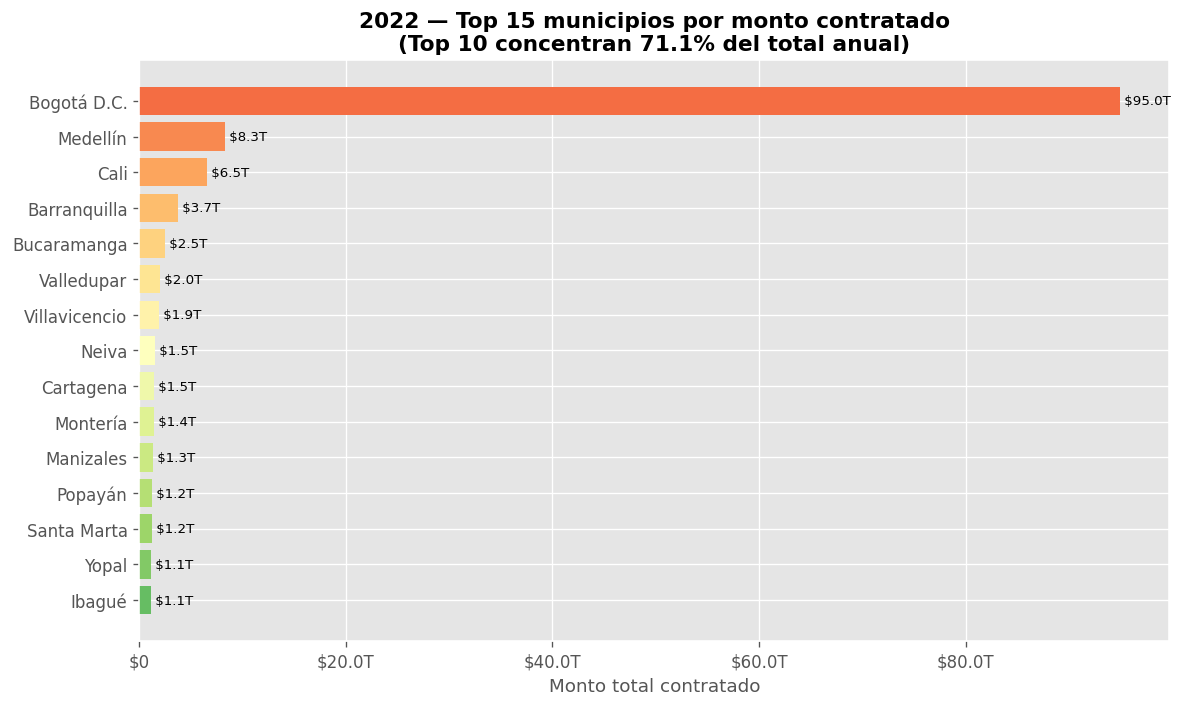

  Monto total 2022: $174.8T


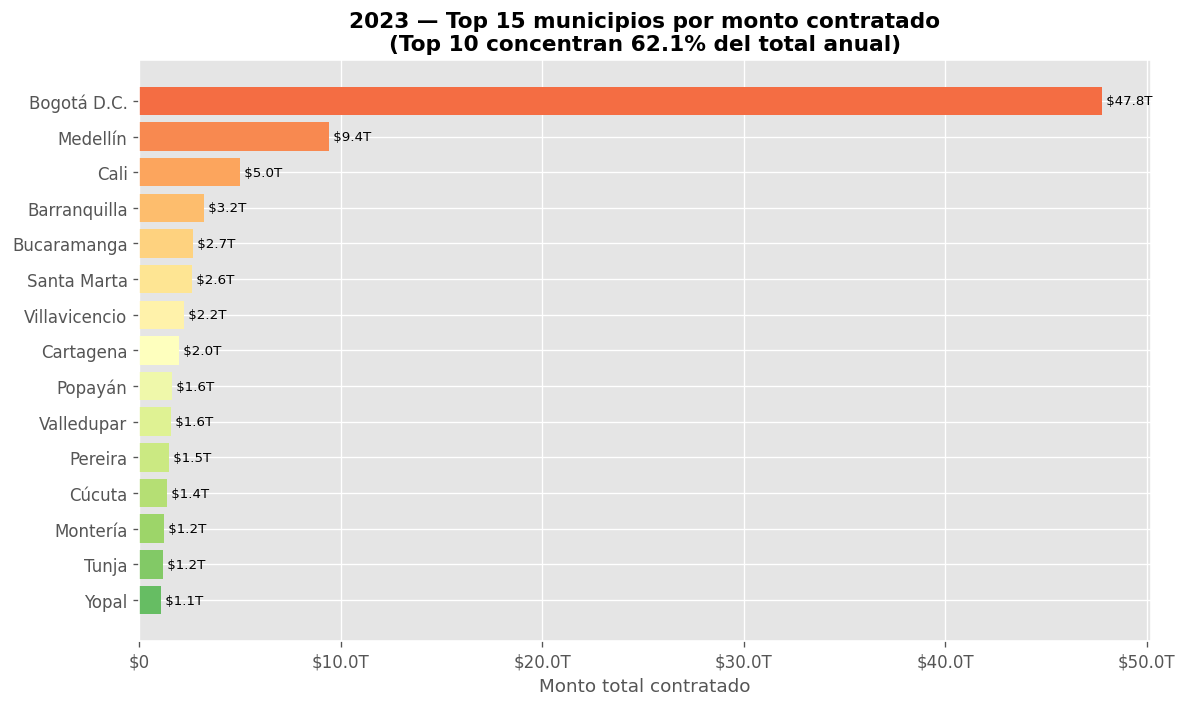

  Monto total 2023: $125.8T


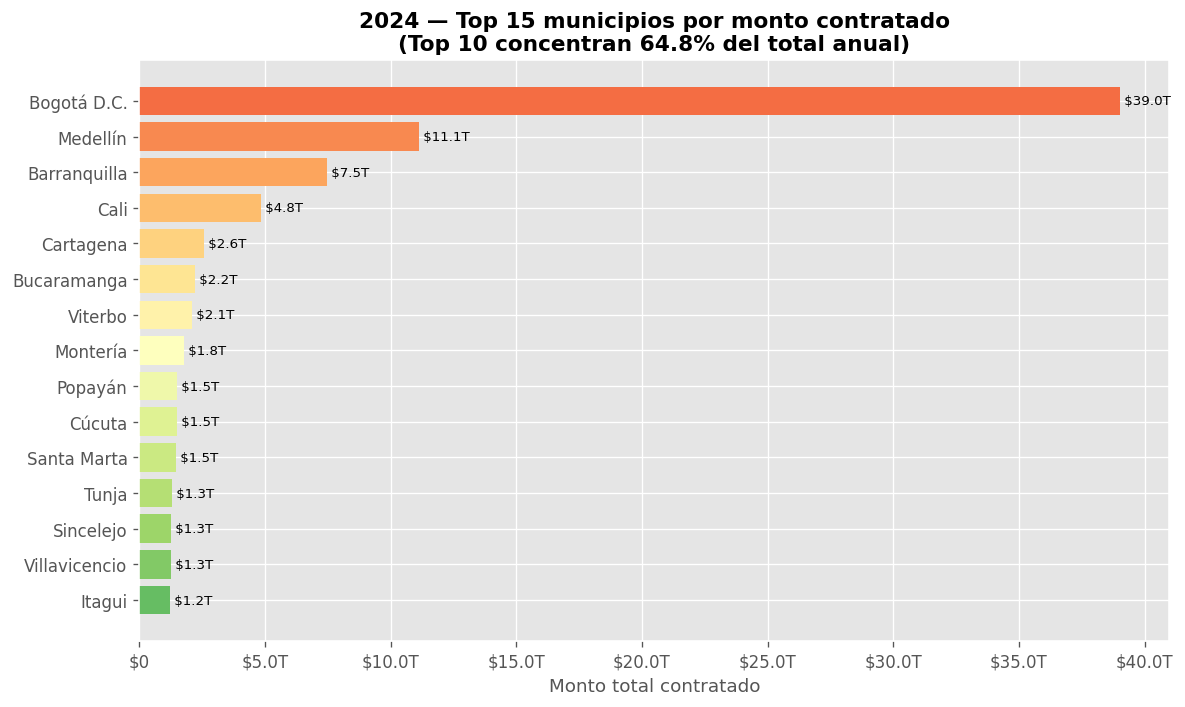

  Monto total 2024: $114.4T


In [6]:
for año in AÑOS:
    sub       = df_mun[df_mun[COL_AÑO] == año]
    total_año = sub[COL_MONTO].sum()
    top15     = sub.nlargest(15, COL_MONTO)
    top10_share = top15.head(10)[COL_MONTO].sum() / total_año * 100 if total_año else 0

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top15)))
    bars = ax.barh(range(len(top15)), top15[COL_MONTO], color=colors)
    ax.set_yticks(range(len(top15)))
    ax.set_yticklabels(top15[COL_MUNICIPIO])
    ax.invert_yaxis()
    ax.set_title(
        f'{año} — Top 15 municipios por monto contratado\n'
        f'(Top 10 concentran {top10_share:.1f}% del total anual)',
        fontweight='bold')
    ax.set_xlabel('Monto total contratado')
    ax.xaxis.set_major_formatter(FuncFormatter(fmt_moneda))
    for bar, val in zip(bars, top15[COL_MONTO]):
        ax.text(val, bar.get_y() + bar.get_height()/2,
                f' {fmt_moneda(val)}', ha='left', va='center', fontsize=8)
    plt.tight_layout(); plt.show()
    print(f'  Monto total {año}: {fmt_moneda(total_año)}')


## 6. Desigualdad — Coeficiente de Gini

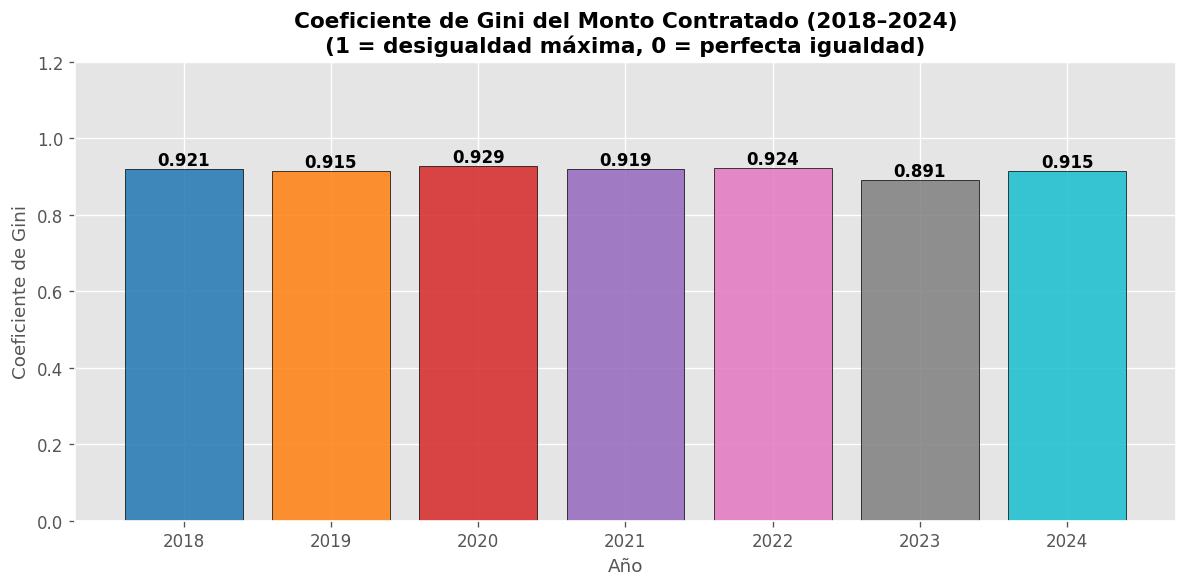


Gini por año (desigualdad en distribución de contratos):
  2018: 0.9212 [|||||||||||||||||||||||||||]
  2019: 0.9147 [|||||||||||||||||||||||||||]
  2020: 0.9289 [|||||||||||||||||||||||||||]
  2021: 0.9194 [|||||||||||||||||||||||||||]
  2022: 0.9239 [|||||||||||||||||||||||||||]
  2023: 0.8911 [||||||||||||||||||||||||||]
  2024: 0.9151 [|||||||||||||||||||||||||||]


In [7]:
ginis = {int(a): gini(df_mun.loc[df_mun[COL_AÑO] == a, COL_MONTO].fillna(0))
         for a in AÑOS}

fig, ax = plt.subplots(figsize=(10, 5))
años_v = list(ginis.keys()); vals_g = list(ginis.values())
bars = ax.bar(años_v, vals_g,
              color=[COLOR_MAP[a] for a in años_v], edgecolor='black', alpha=0.85)
ax.set_title('Coeficiente de Gini del Monto Contratado (2018–2024)\n'
             '(1 = desigualdad máxima, 0 = perfecta igualdad)', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Coeficiente de Gini')
ax.set_ylim(0, 1.2)
for bar, val in zip(bars, vals_g):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nGini por año (desigualdad en distribución de contratos):')
for a, g_val in ginis.items():
    if pd.isna(g_val):
        barra = "N/A"
    else:
            barra = '|' * int(g_val * 30)
    print(f'  {a}: {g_val:.4f} [{barra}]')


## 7. Relación inversión–vulnerabilidad (NBI vs log Monto)

Dispersión de municipios por año: eje X = NBI (%), eje Y = log₁₀ del monto contratado. La línea roja es la tendencia lineal y `r` es la correlación de Pearson.

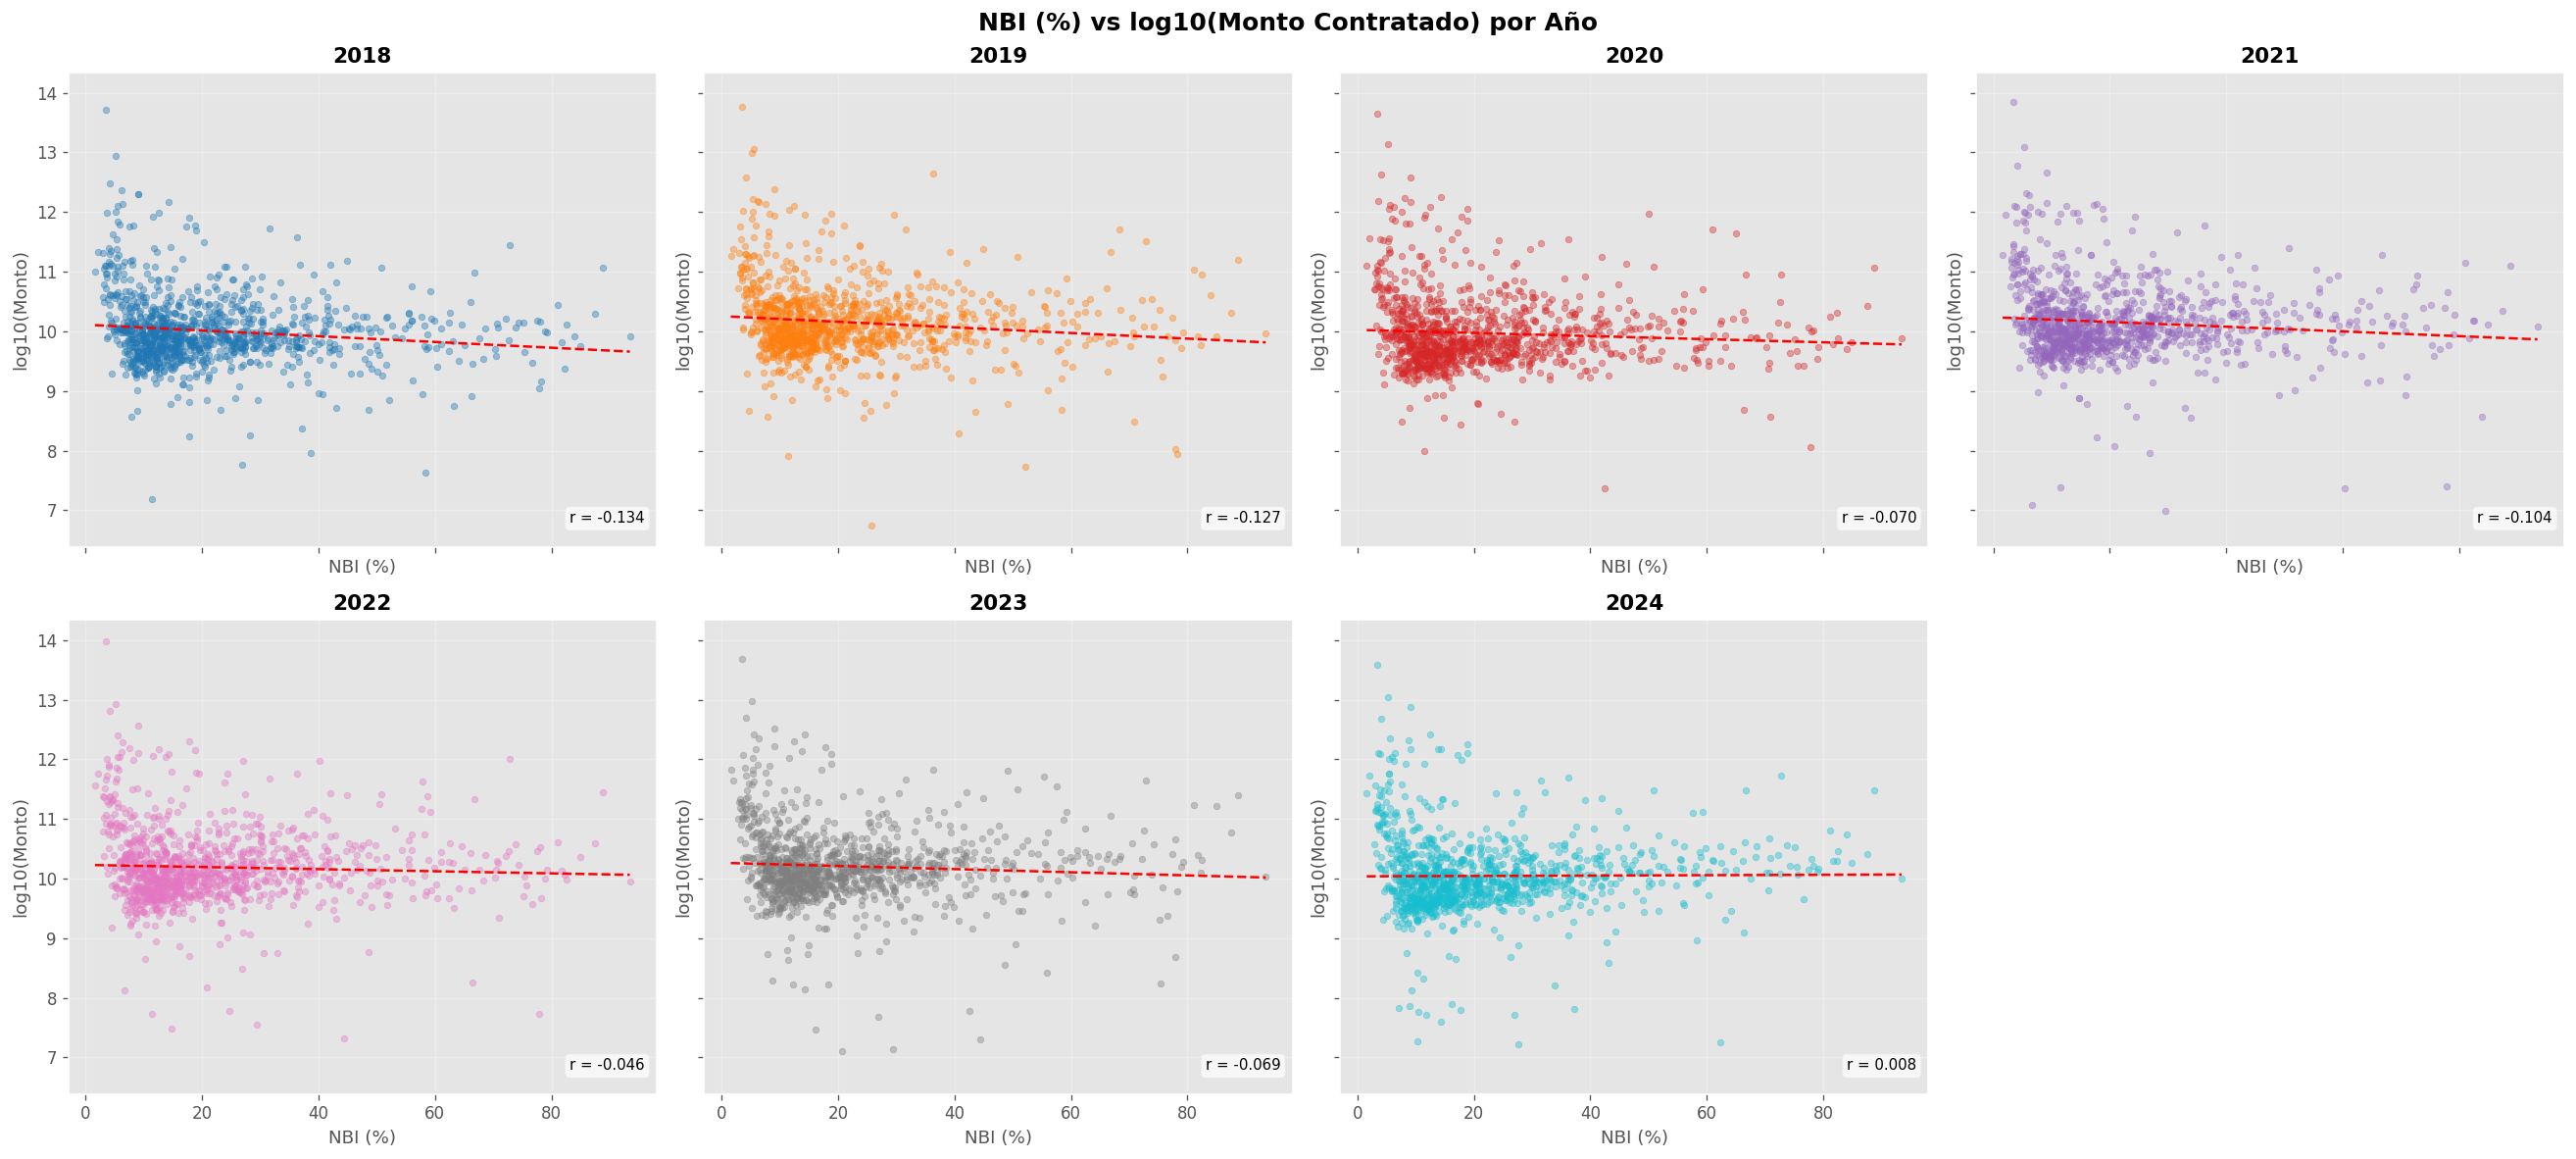


Correlacion Pearson NBI vs log10(Monto) por año:


,r_NBI_logMonto,n
año,,
2018,-0.1337,1071
2019,-0.1268,1073
2020,-0.0704,1077
2021,-0.1040,1080
2022,-0.0462,1084
2023,-0.0686,1081
2024,0.0083,1087


In [8]:
if COL_NBI in df_mun.columns and not df_mun[COL_NBI].isna().all():
    corrs = []
    fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharex=True, sharey=True)
    fig.suptitle('NBI (%) vs log10(Monto Contratado) por Año',
                 fontsize=15, fontweight='bold')

    for idx, año in enumerate(AÑOS):
        ax = axes[idx // 4][idx % 4]
        sub = df_mun[(df_mun[COL_AÑO] == año) & (df_mun[COL_MONTO] > 0)] \
                    .dropna(subset=[COL_NBI]).copy()
        sub['log_monto'] = np.log10(sub[COL_MONTO])

        ax.scatter(sub[COL_NBI], sub['log_monto'],
                   alpha=0.4, s=15, color=COLOR_MAP[año])
        if len(sub) > 2:
            z = np.polyfit(sub[COL_NBI], sub['log_monto'], 1)
            p = np.poly1d(z)
            xr = np.linspace(sub[COL_NBI].min(), sub[COL_NBI].max(), 100)
            ax.plot(xr, p(xr), 'r--', linewidth=1.5)
            r = sub[COL_NBI].corr(sub['log_monto'])
            corrs.append({'año': año, 'r_NBI_logMonto': round(r, 4), 'n': len(sub)})
            ax.text(0.98, 0.05, f'r = {r:.3f}', transform=ax.transAxes,
                    ha='right', fontsize=9,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        ax.set_title(str(año), fontweight='bold')
        ax.set_xlabel('NBI (%)'); ax.set_ylabel('log10(Monto)')
        ax.grid(True, alpha=0.3)

    axes[1][3].set_visible(False)
    plt.tight_layout(); plt.show()

    print('\nCorrelacion Pearson NBI vs log10(Monto) por año:')
    display(pd.DataFrame(corrs).set_index('año'))
else:
    print('NBI no disponible para este análisis.')


## 8. Análisis por departamento y región geográfica

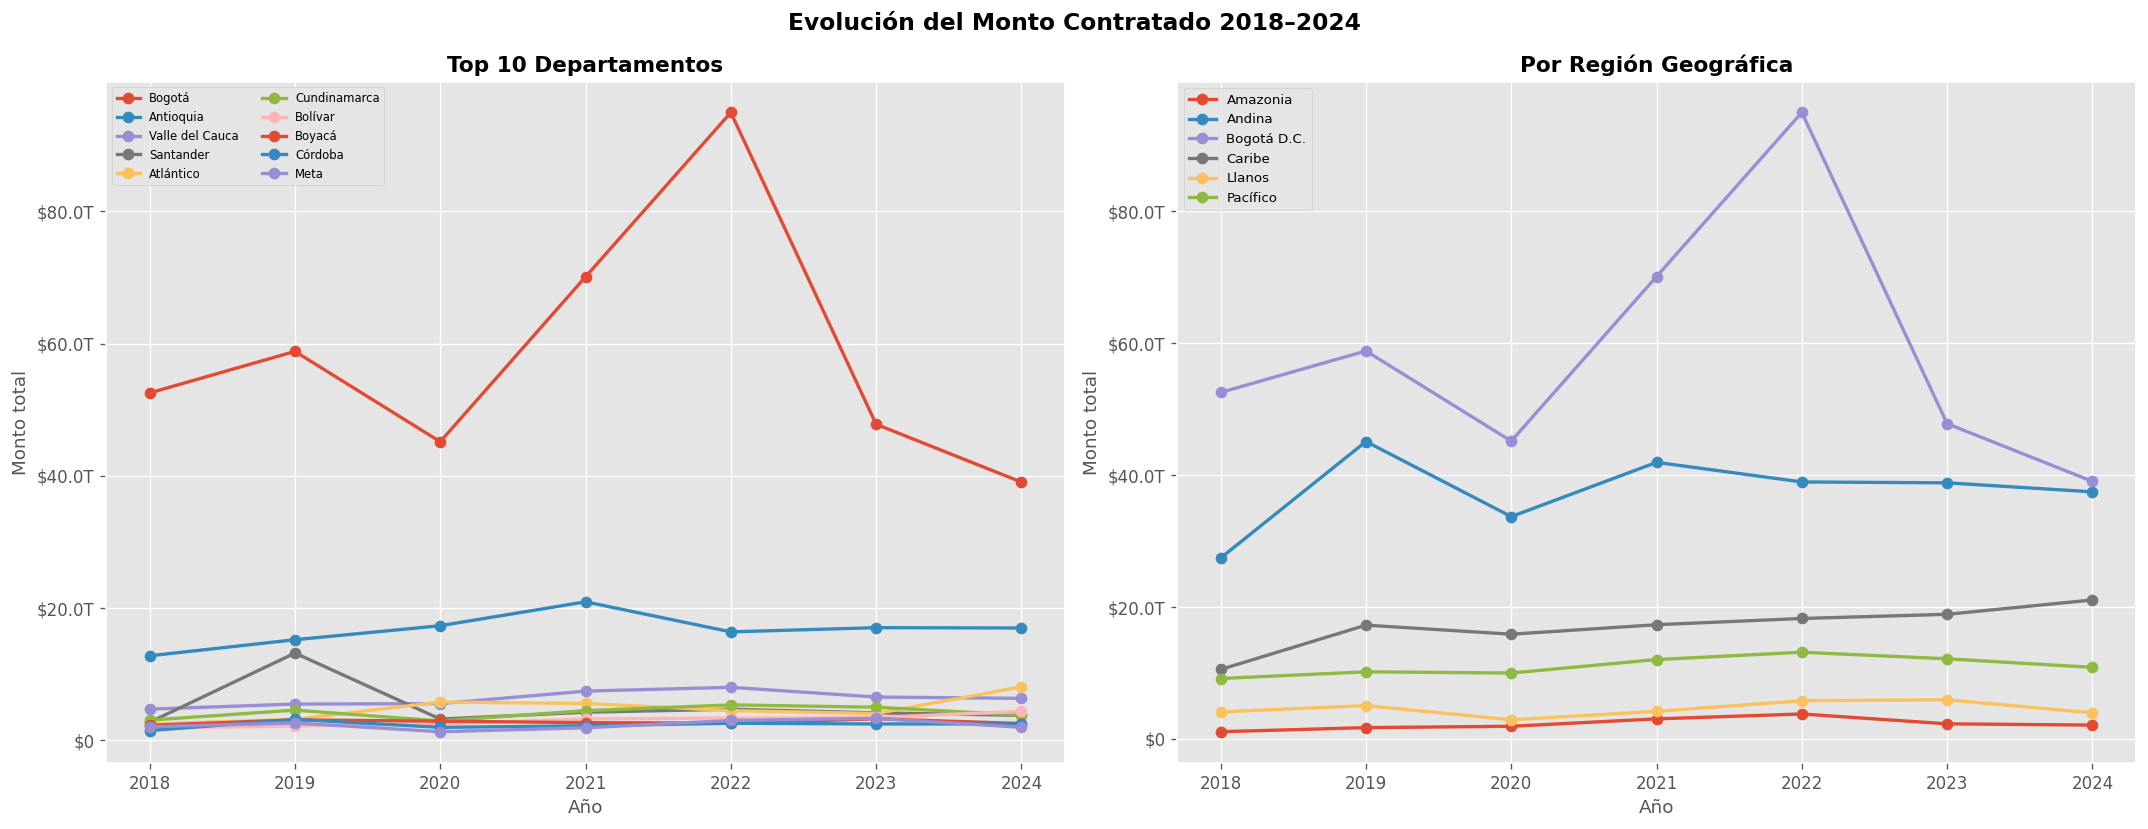


Monto acumulado 2018-2024 por departamento (Top 15):


,monto_acumulado
nombre_departamento,
Bogotá,$408.4T
Antioquia,$116.4T
Valle del Cauca,$43.8T
Santander,$35.7T
Atlántico,$33.3T
Cundinamarca,$28.9T
Bolívar,$20.6T
Boyacá,$18.9T
Córdoba,$16.0T


In [9]:
dep_año = df_mun.groupby([COL_DEPTO, COL_AÑO]).agg(
    monto_total   = (COL_MONTO,     'sum'),
    num_contratos = (COL_CONTRATOS,  'sum'),
).reset_index()
dep_año[COL_AÑO] = dep_año[COL_AÑO].astype(int)

top10_dep = (df_mun.groupby(COL_DEPTO)[COL_MONTO]
               .sum().nlargest(10).index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Evolución del Monto Contratado 2018–2024', fontsize=14, fontweight='bold')

ax = axes[0]
for dep in top10_dep:
    sub = dep_año[dep_año[COL_DEPTO] == dep].sort_values(COL_AÑO)
    ax.plot(sub[COL_AÑO], sub['monto_total'], marker='o', linewidth=2, label=dep)
ax.yaxis.set_major_formatter(FuncFormatter(fmt_moneda))
ax.set_title('Top 10 Departamentos', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Monto total')
ax.legend(loc='upper left', fontsize=7, ncol=2)
ax.set_xticks(AÑOS)

ax = axes[1]
reg_año = df_mun.groupby(['region', COL_AÑO]).agg(
    monto_total = (COL_MONTO, 'sum')
).reset_index()
reg_año[COL_AÑO] = reg_año[COL_AÑO].astype(int)
for reg in sorted(r for r in df_mun['region'].dropna().unique() if r):
    sub = reg_año[reg_año['region'] == reg].sort_values(COL_AÑO)
    ax.plot(sub[COL_AÑO], sub['monto_total'], marker='o', linewidth=2, label=reg)
ax.yaxis.set_major_formatter(FuncFormatter(fmt_moneda))
ax.set_title('Por Región Geográfica', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Monto total')
ax.legend(loc='upper left', fontsize=8)
ax.set_xticks(AÑOS)

plt.tight_layout(); plt.show()

print('\nMonto acumulado 2018-2024 por departamento (Top 15):')
display(df_mun.groupby(COL_DEPTO)[COL_MONTO].sum().nlargest(15)
        .apply(fmt_moneda).to_frame('monto_acumulado'))


## 9. Cuadrantes de abandono relativo por año

**Rojo** = alta necesidad (NBI > mediana) con poca inversión (monto < mediana). Estos municipios son los candidatos prioritarios para política pública.

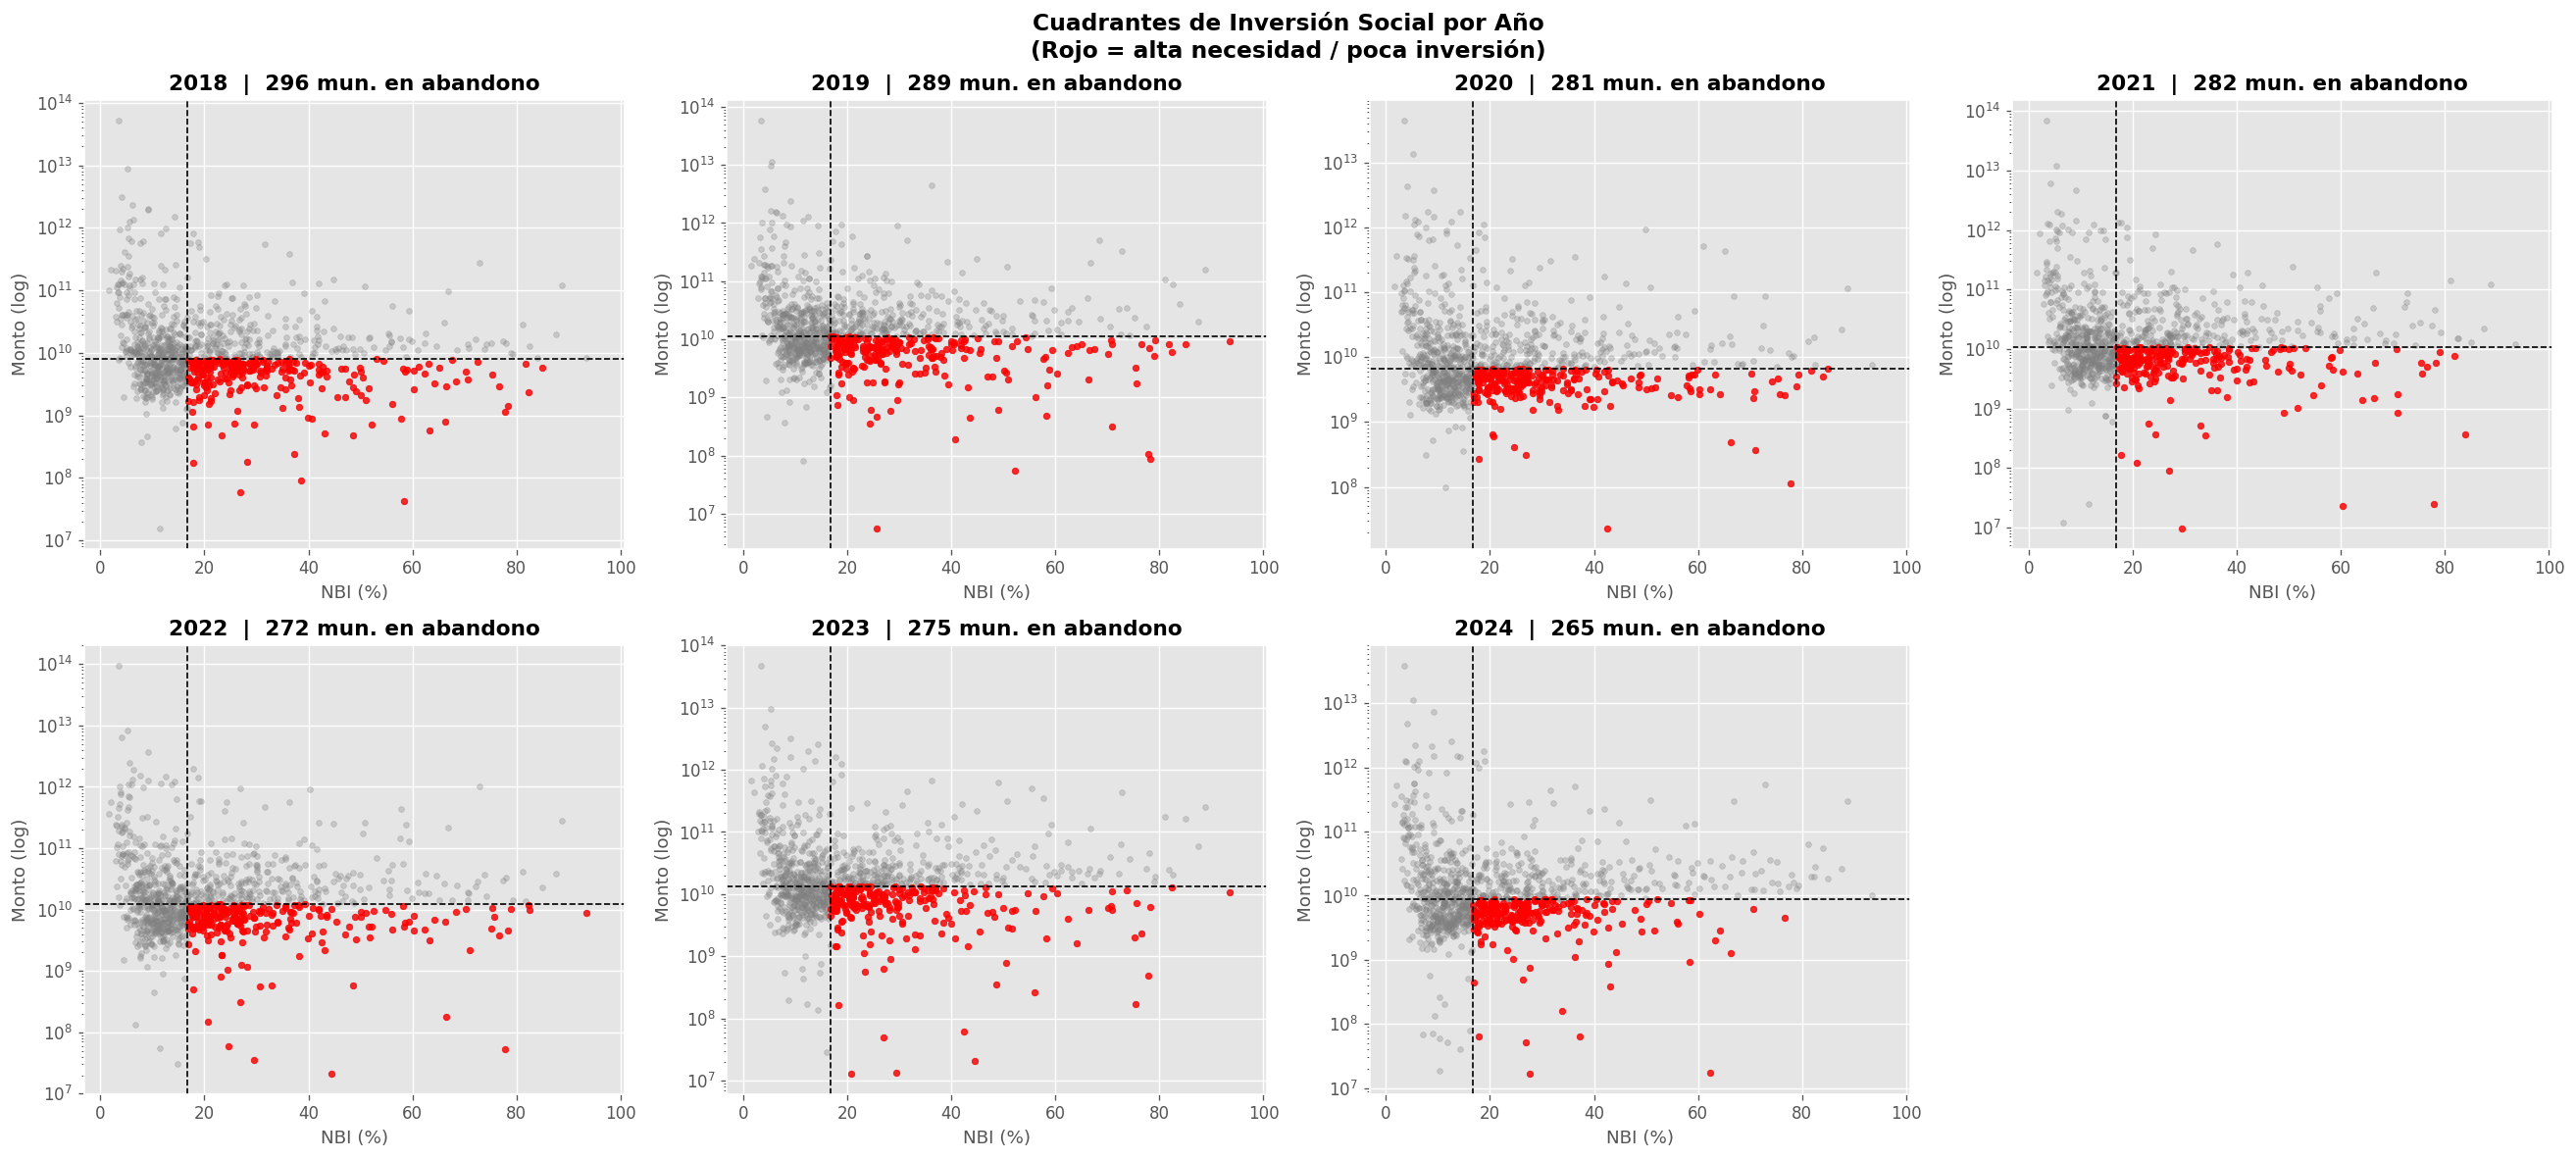


Municipios en cuadrante de abandono relativo por año:


,municipios_prioritarios,pct_sobre_total
año,,
2018,296,26.4
2019,289,25.8
2020,281,25.0
2021,282,25.1
2022,272,24.2
2023,275,24.5
2024,265,23.6


In [10]:
if COL_NBI in df_mun.columns and not df_mun[COL_NBI].isna().all():
    resumen_cuadrantes = []
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    fig.suptitle('Cuadrantes de Inversión Social por Año\n'
                 '(Rojo = alta necesidad / poca inversión)',
                 fontsize=14, fontweight='bold')

    for idx, año in enumerate(AÑOS):
        ax = axes[idx // 4][idx % 4]
        sub = df_mun[df_mun[COL_AÑO] == año].dropna(subset=[COL_NBI]).copy()
        med_nbi   = sub[COL_NBI].median()
        med_monto = sub[COL_MONTO].median()

        prioritarios = sub[
            (sub[COL_NBI]   > med_nbi) &
            (sub[COL_MONTO] <= med_monto)
        ]
        resumen_cuadrantes.append({
            'año': año,
            'municipios_prioritarios': len(prioritarios),
            'pct_sobre_total': round(len(prioritarios) / len(sub) * 100, 1)
        })
        ax.scatter(sub[COL_NBI], sub[COL_MONTO], alpha=0.3, color='gray', s=12)
        ax.scatter(prioritarios[COL_NBI], prioritarios[COL_MONTO],
                   alpha=0.8, color='red', s=15)
        ax.axvline(med_nbi,   color='black', linestyle='--', linewidth=1)
        ax.axhline(med_monto, color='black', linestyle='--', linewidth=1)
        ax.set_yscale('log')
        ax.set_title(f'{año}  |  {len(prioritarios)} mun. en abandono', fontweight='bold')
        ax.set_xlabel('NBI (%)'); ax.set_ylabel('Monto (log)')

    axes[1][3].set_visible(False)
    plt.tight_layout(); plt.show()

    print('\nMunicipios en cuadrante de abandono relativo por año:')
    display(pd.DataFrame(resumen_cuadrantes).set_index('año'))


## 10. Municipios críticos — Alta pobreza, cero contratos

Municipios con NBI > P75 y 0 contratos:


,umbral_nbi_p75,municipios_criticos,pct
año,,,
2018,28.7,33,2.9
2019,28.7,31,2.8
2020,28.7,31,2.8
2021,28.7,31,2.8
2022,28.7,29,2.6
2023,28.7,30,2.7
2024,28.7,29,2.6


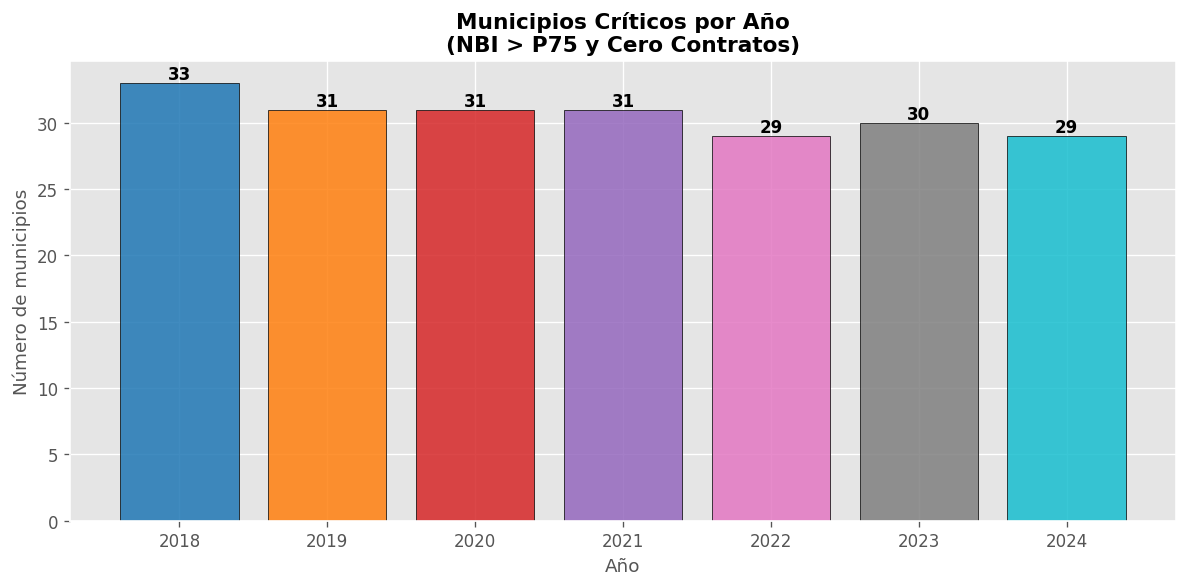


Top 10 municipios críticos en 2024:


,nombre_departamento,nombre_municipio_referencia,nbi_pct,region
8035,Guainía,Puerto Colombia (anm),95.963756,Amazonia
8070,Vaupés,Pacoa (anm),93.647469,Amazonia
8042,Guainía,La Guadalupe (anm),93.630573,Amazonia
8056,Guainía,Pana Pana (anm),93.601651,Amazonia
8063,Guainía,Morichal (anm),92.366412,Amazonia
7972,Amazonas,La Victoria (anm),90.963855,Amazonia
8028,Guainía,San Felipe (anm),88.391225,Amazonia
8077,Vaupés,Papunaua (anm),87.037037,Amazonia
7979,Amazonas,Miriti - Paraná (anm),85.764706,Amazonia
7965,Amazonas,La Pedrera (anm),78.831909,Amazonia


In [11]:
if COL_NBI in df_mun.columns and not df_mun[COL_NBI].isna().all():
    criticos_res = []
    for año in AÑOS:
        sub = df_mun[df_mun[COL_AÑO] == año].dropna(subset=[COL_NBI])
        umbral = sub[COL_NBI].quantile(0.75)
        criticos = sub[(sub[COL_NBI] >= umbral) & (sub[COL_MONTO] == 0)]
        criticos_res.append({
            'año': año,
            'umbral_nbi_p75': round(umbral, 1),
            'municipios_criticos': len(criticos),
            'pct': round(len(criticos) / len(sub) * 100, 1)
        })

    df_criticos = pd.DataFrame(criticos_res).set_index('año')
    print('Municipios con NBI > P75 y 0 contratos:')
    display(df_criticos)

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(df_criticos.index, df_criticos['municipios_criticos'],
                  color=[COLOR_MAP[a] for a in df_criticos.index],
                  edgecolor='black', alpha=0.85)
    ax.set_title('Municipios Críticos por Año\n(NBI > P75 y Cero Contratos)',
                 fontweight='bold')
    ax.set_xlabel('Año'); ax.set_ylabel('Número de municipios')
    for bar, val in zip(bars, df_criticos['municipios_criticos']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha='center', fontsize=10, fontweight='bold')
    plt.tight_layout(); plt.show()

    último_año = AÑOS[-1]
    sub_ult = df_mun[df_mun[COL_AÑO] == último_año].dropna(subset=[COL_NBI])
    umbral_ult = sub_ult[COL_NBI].quantile(0.75)
    criticos_ult = sub_ult[(sub_ult[COL_NBI] >= umbral_ult) & (sub_ult[COL_MONTO] == 0)]
    print(f'\nTop 10 municipios críticos en {último_año}:')
    display(criticos_ult.nlargest(10, COL_NBI)
            [[COL_DEPTO, COL_MUNICIPIO, COL_NBI, 'region']])


## 11. Ticket promedio por cuartil de NBI y año

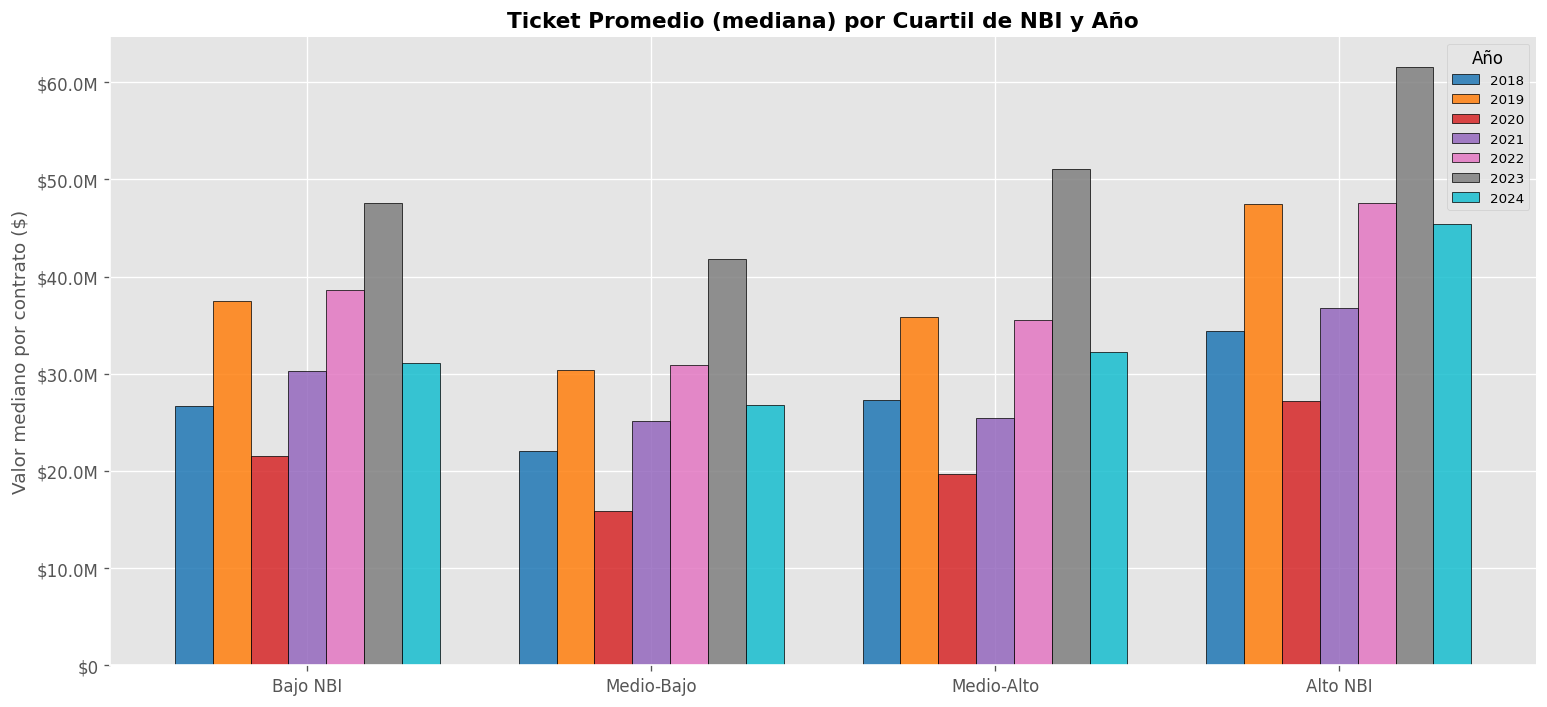


Ticket promedio mediano por cuartil y año:


cuartil_nbi,Bajo NBI,Medio-Bajo,Medio-Alto,Alto NBI
2018,$26.7M,$22.0M,$27.3M,$34.4M
2019,$37.5M,$30.4M,$35.9M,$47.5M
2020,$21.6M,$15.9M,$19.7M,$27.2M
2021,$30.3M,$25.2M,$25.5M,$36.8M
2022,$38.6M,$30.9M,$35.6M,$47.6M
2023,$47.6M,$41.8M,$51.1M,$61.6M
2024,$31.1M,$26.8M,$32.3M,$45.4M


In [12]:
if COL_NBI in df_mun.columns and not df_mun[COL_NBI].isna().all():
    df_mun = df_mun.copy()
    df_mun['ticket_promedio'] = df_mun[COL_MONTO] / df_mun[COL_CONTRATOS].replace(0, np.nan)
    ticket_anual = []
    for año in AÑOS:
        sub = df_mun[df_mun[COL_AÑO] == año].dropna(subset=[COL_NBI, 'ticket_promedio']).copy()
        sub['cuartil_nbi'] = pd.qcut(sub[COL_NBI], 4,
                                      labels=['Bajo NBI', 'Medio-Bajo', 'Medio-Alto', 'Alto NBI'])
        med_tick = sub.groupby('cuartil_nbi', observed=False)['ticket_promedio'].median()
        med_tick.name = año
        ticket_anual.append(med_tick)

    ticket_df = pd.DataFrame(ticket_anual)

    fig, ax = plt.subplots(figsize=(13, 6))
    x = np.arange(len(ticket_df.columns))
    width = 0.11
    for i, (año, row) in enumerate(ticket_df.iterrows()):
        ax.bar(x + i * width, row.values, width,
               label=str(año), color=COLOR_MAP[int(año)], edgecolor='black', alpha=0.85)
    ax.set_title('Ticket Promedio (mediana) por Cuartil de NBI y Año', fontweight='bold')
    ax.set_xticks(x + width * (len(AÑOS) - 1) / 2)
    ax.set_xticklabels(ticket_df.columns)
    ax.set_ylabel('Valor mediano por contrato ($)')
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_moneda))
    ax.legend(title='Año', fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout(); plt.show()

    print('\nTicket promedio mediano por cuartil y año:')
    display(ticket_df.map(lambda x: fmt_moneda(x) if pd.notna(x) else 'N/A'))


## 12. Matrices de correlación anuales

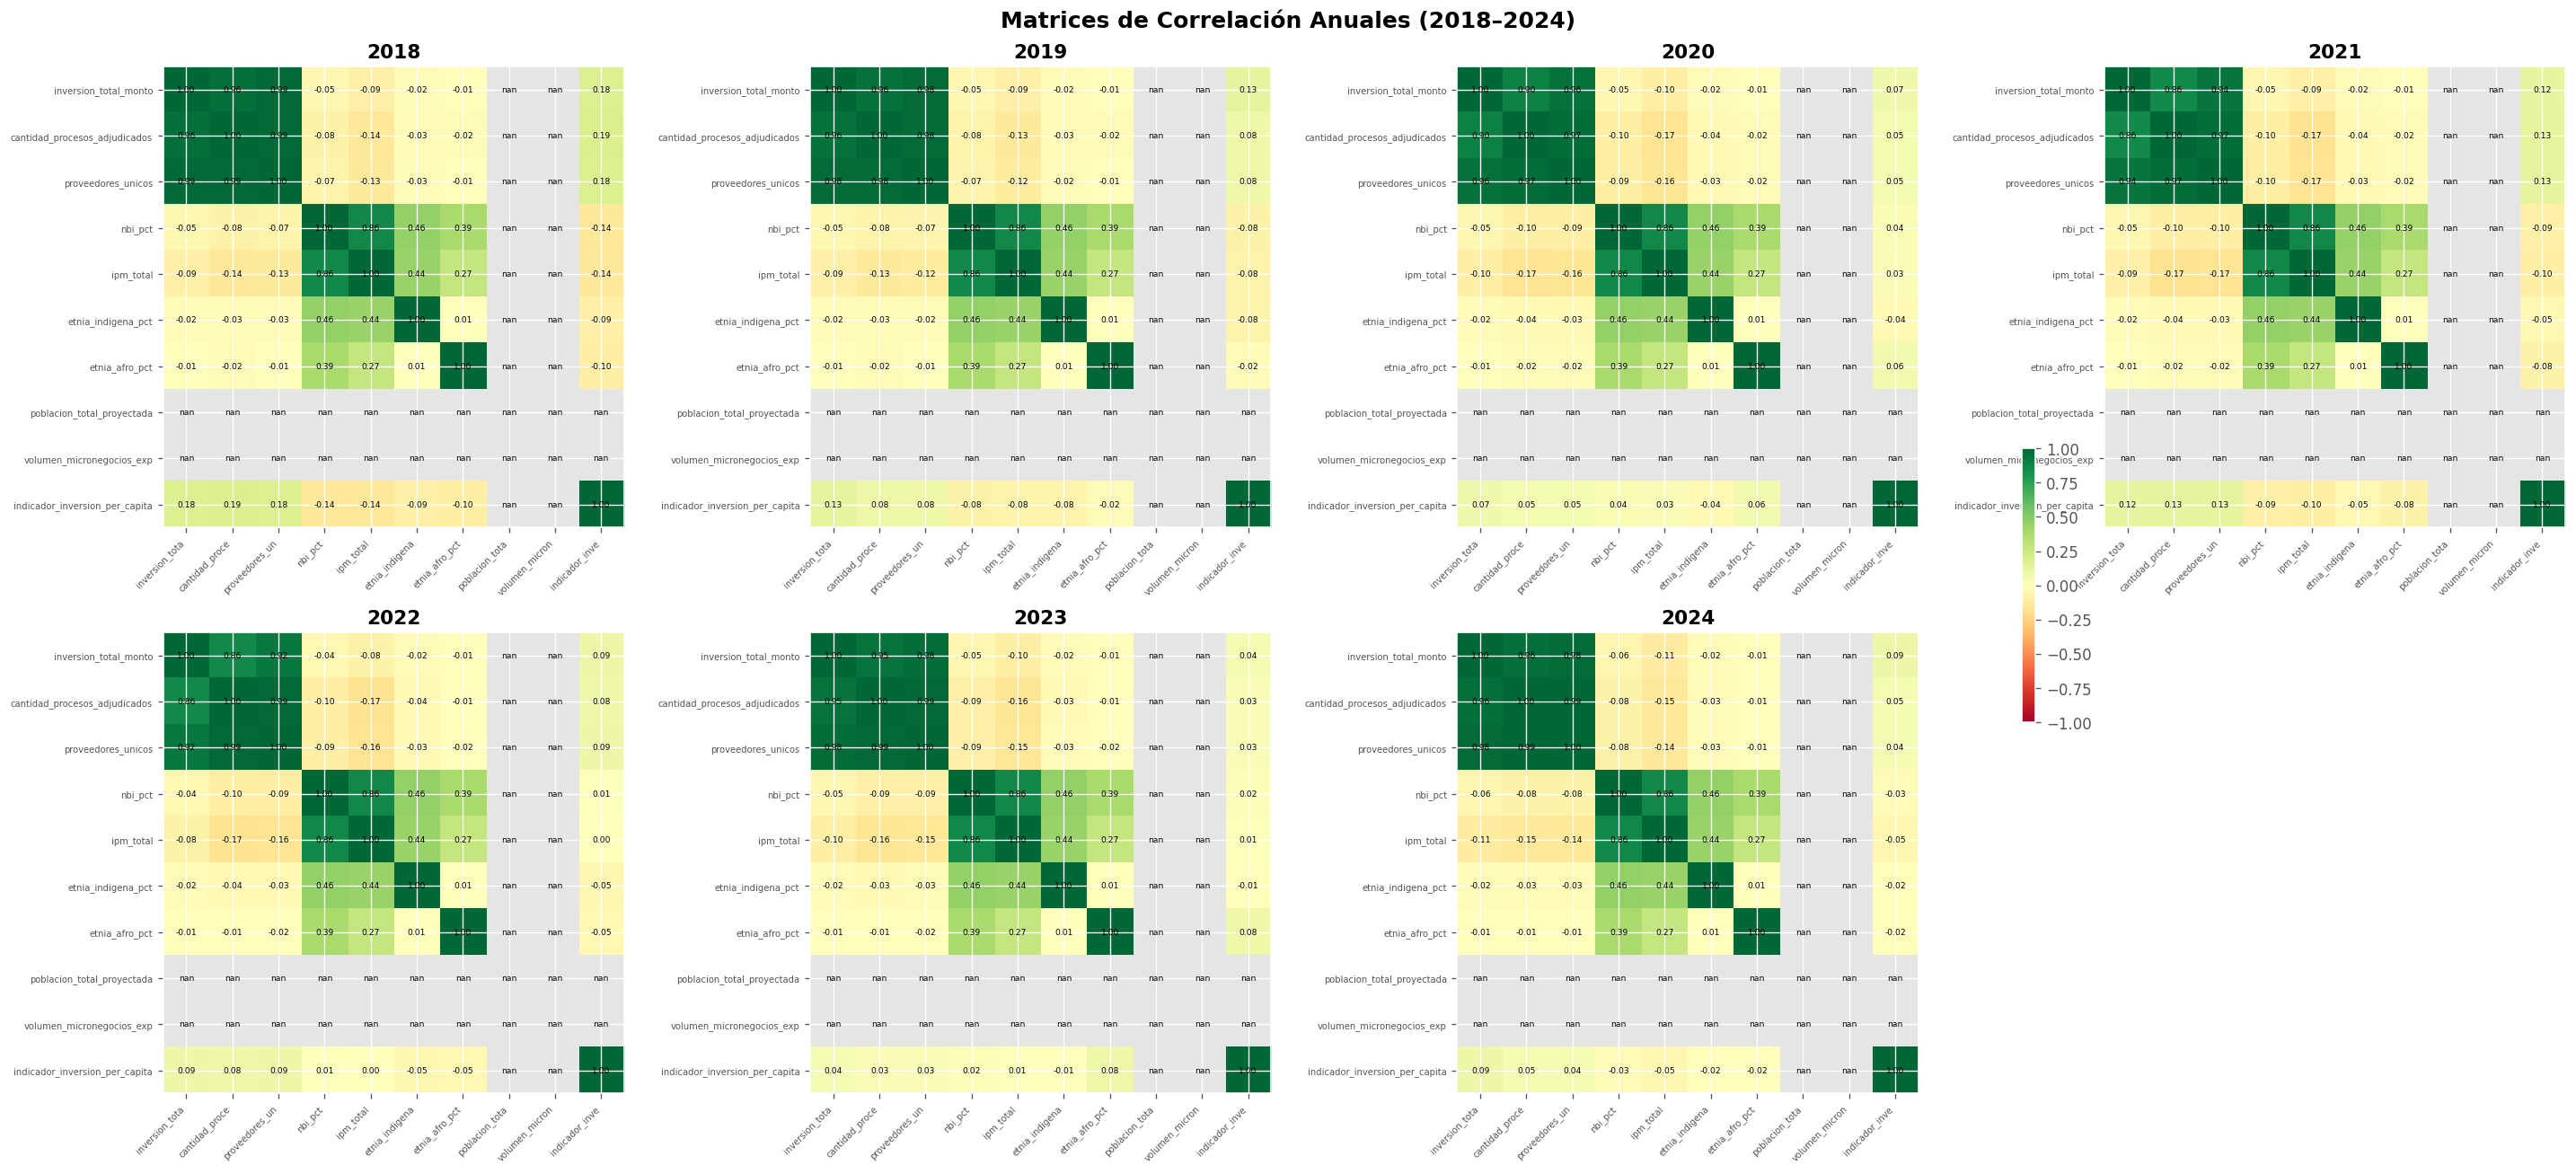

In [13]:
_COLS_CORR_CAND = [
    COL_MONTO, COL_CONTRATOS, 'proveedores_unicos',
    COL_NBI, COL_IPM, 'etnia_indigena_pct', 'etnia_afro_pct',
    'poblacion_total_proyectada', 'volumen_micronegocios_exp',
    'indicador_inversion_per_capita',
]
COLS_CORR = [c for c in _COLS_CORR_CAND if c in df_mun.columns]
etiquetas_corr = [c[:14] for c in COLS_CORR]

fig, axes = plt.subplots(2, 4, figsize=(24, 11))
fig.suptitle('Matrices de Correlación Anuales (2018–2024)', fontsize=15, fontweight='bold')

im_last = None
for idx, año in enumerate(AÑOS):
    ax = axes[idx // 4][idx % 4]
    corr = df_mun[df_mun[COL_AÑO] == año][COLS_CORR].corr()
    im_last = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
    ax.set_xticks(range(len(COLS_CORR)))
    ax.set_xticklabels(etiquetas_corr, rotation=45, ha='right', fontsize=6)
    ax.set_yticks(range(len(COLS_CORR)))
    ax.set_yticklabels(COLS_CORR, fontsize=6)
    for i in range(len(COLS_CORR)):
        for j in range(len(COLS_CORR)):
            ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                    color='black', fontsize=5.5)
    ax.set_title(str(año), fontweight='bold')

axes[1][3].set_visible(False)
if im_last is not None:
    fig.colorbar(im_last, ax=axes.ravel().tolist(), shrink=0.3)
plt.tight_layout(); plt.show()


## 13. Alta vulnerabilidad vs. inversión recibida

¿Qué proporción del monto total llega a los municipios con NBI mayor o igual a la mediana anual?

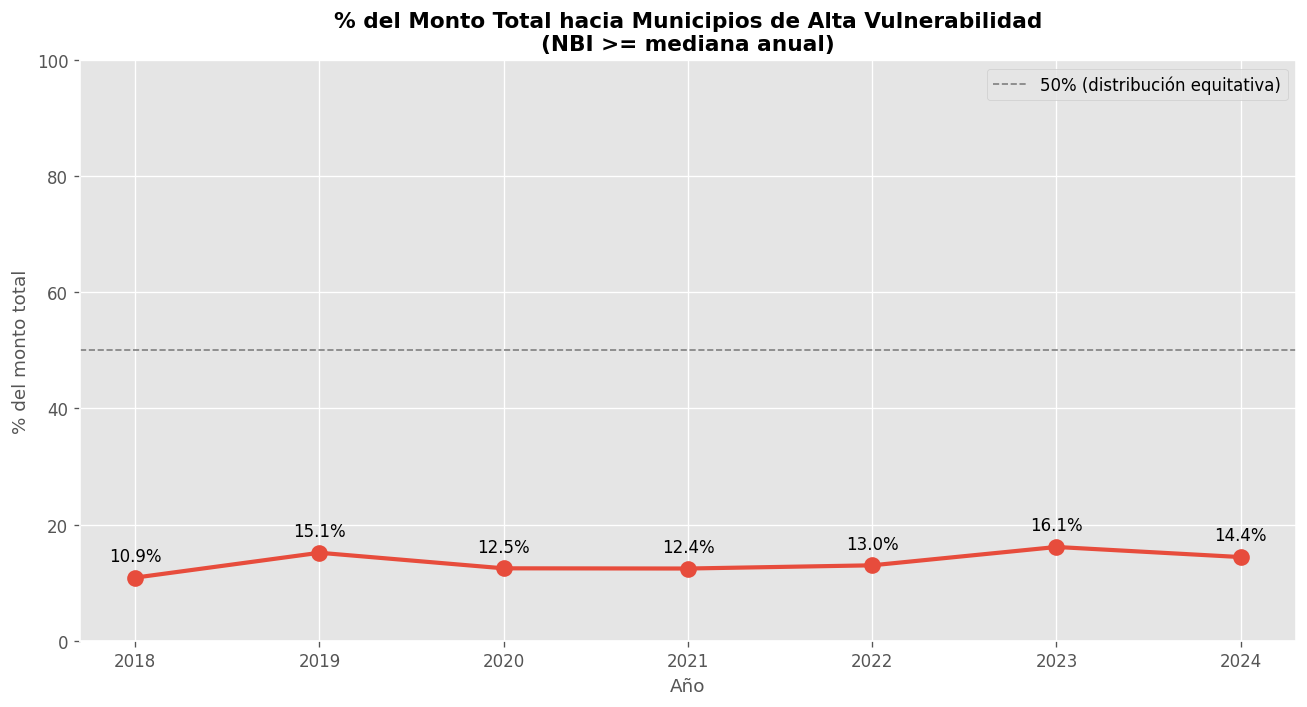


% del monto hacia alta vulnerabilidad por año:


,pct_monto_alta_vul
año,
2018,10.86
2019,15.14
2020,12.46
2021,12.43
2022,12.98
2023,16.14
2024,14.40


In [14]:
if COL_NBI in df_mun.columns and not df_mun[COL_NBI].isna().all():
    grupos_res = []
    for año in AÑOS:
        sub = df_mun[df_mun[COL_AÑO] == año].dropna(subset=[COL_NBI]).copy()
        med_nbi = sub[COL_NBI].median()
        sub['grupo'] = np.where(sub[COL_NBI] >= med_nbi,
                                'Alta vulnerabilidad', 'Baja vulnerabilidad')
        res = sub.groupby('grupo').agg(
            municipios  = (COL_DIVIPOLA,  'count'),
            monto_total = (COL_MONTO,     'sum'),
            contratos   = (COL_CONTRATOS,  'sum'),
        ).reset_index()
        res['año'] = año
        grupos_res.append(res)

    df_grupos = pd.concat(grupos_res)
    alta = df_grupos[df_grupos['grupo'] == 'Alta vulnerabilidad'].set_index('año')
    total_monto_año = df_grupos.groupby('año')['monto_total'].sum()
    pct_alta = (alta['monto_total'] / total_monto_año * 100).rename('pct_monto_alta_vul')

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.plot(pct_alta.index, pct_alta.values, marker='o', linewidth=2.5,
            color='#E74C3C', markersize=9)
    ax.axhline(50, color='gray', linestyle='--', linewidth=1,
               label='50% (distribución equitativa)')
    ax.set_title('% del Monto Total hacia Municipios de Alta Vulnerabilidad\n'
                 '(NBI >= mediana anual)', fontweight='bold')
    ax.set_xlabel('Año'); ax.set_ylabel('% del monto total')
    ax.set_ylim(0, 100); ax.set_xticks(AÑOS)
    for x, y in zip(pct_alta.index, pct_alta.values):
        ax.annotate(f'{y:.1f}%', (x, y),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=10)
    ax.legend()
    plt.tight_layout(); plt.show()

    print('\n% del monto hacia alta vulnerabilidad por año:')
    display(pct_alta.round(2).to_frame())


## 14. Micronegocios y Economía Popular (EMICRON)

> EMICRON tiene granularidad departamental. El mart Gold propaga el dato a los municipios de cada departamento. Aquí usamos los agregados departamentales directamente.

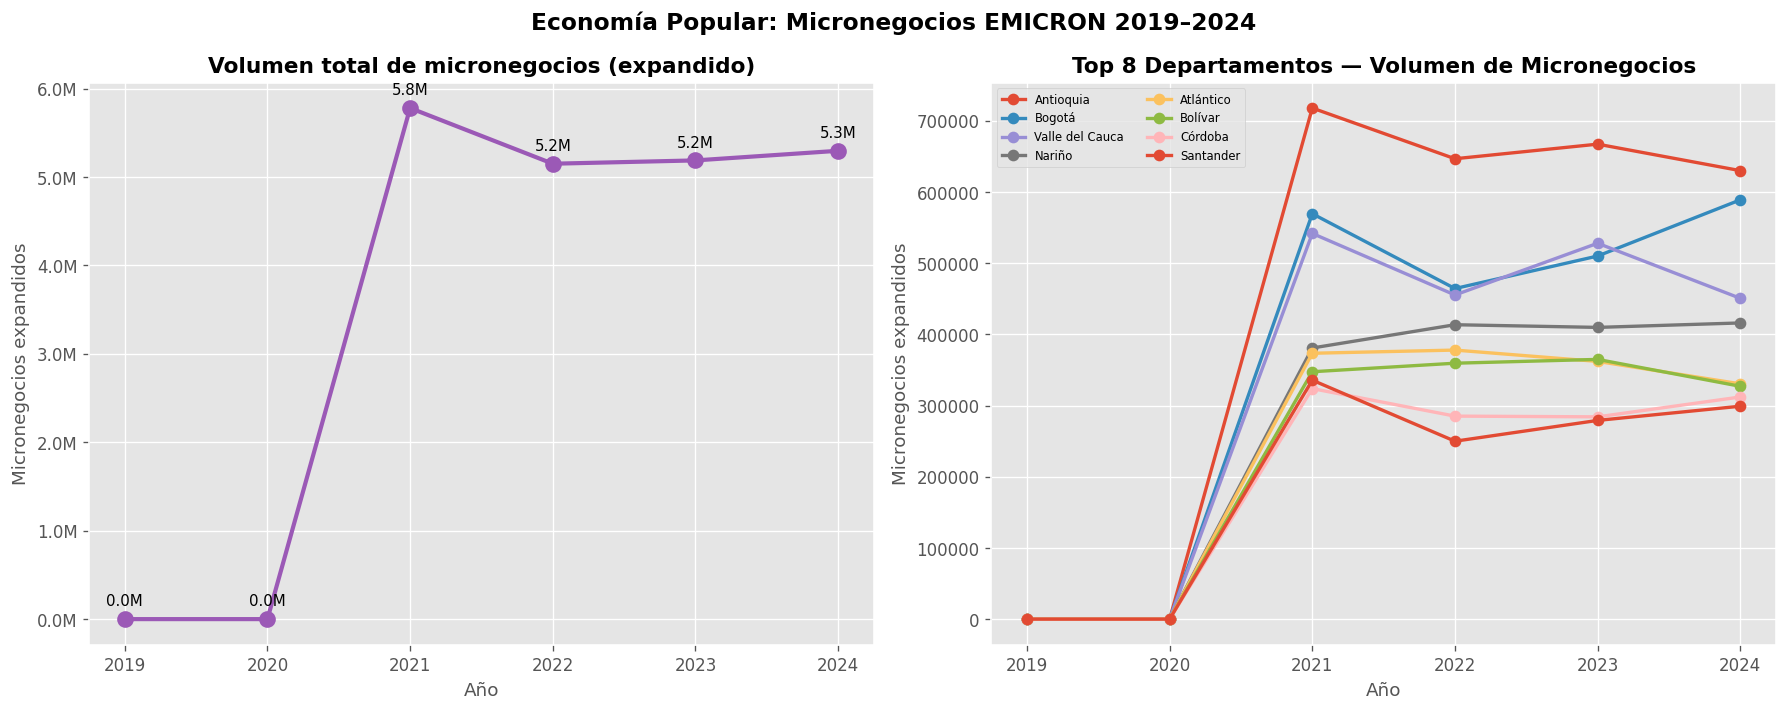

In [15]:
# Agregados departamentales del mart (códigos XX000)
df_depto = df[df['divipola_key'].str.endswith('000')].copy()
df_depto[COL_AÑO] = df_depto[COL_AÑO].astype(int)
AÑOS_MIC = list(range(2019, 2025))  # EMICRON arranca en 2019

_mic_ok = (
    'volumen_micronegocios_exp' in df_depto.columns
    and df_depto['volumen_micronegocios_exp'].gt(0).any()
)

if _mic_ok:
    evol_mic = (df_depto[df_depto[COL_AÑO].isin(AÑOS_MIC)]
                .groupby(COL_AÑO)
                .agg(vol_total = ('volumen_micronegocios_exp', 'sum'))
                .reset_index())

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Economía Popular: Micronegocios EMICRON 2019–2024',
                 fontsize=14, fontweight='bold')

    ax = axes[0]
    ax.plot(evol_mic[COL_AÑO], evol_mic['vol_total'],
            marker='o', linewidth=2.5, color='#9B59B6', markersize=9)
    ax.set_title('Volumen total de micronegocios (expandido)', fontweight='bold')
    ax.set_xlabel('Año'); ax.set_ylabel('Micronegocios expandidos')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    for x, y in zip(evol_mic[COL_AÑO], evol_mic['vol_total']):
        ax.annotate(f'{y/1e6:.1f}M', (x, y),
                    textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

    ax = axes[1]
    top_dep_mic = (df_depto[df_depto[COL_AÑO].isin(AÑOS_MIC)]
                   .groupby(COL_DEPTO)['volumen_micronegocios_exp']
                   .sum().nlargest(8).index.tolist())
    for dep in top_dep_mic:
        sub = df_depto[(df_depto[COL_DEPTO] == dep) &
                       (df_depto[COL_AÑO].isin(AÑOS_MIC))]
        ax.plot(sub[COL_AÑO], sub['volumen_micronegocios_exp'],
                marker='o', linewidth=2, label=dep)
    ax.set_title('Top 8 Departamentos — Volumen de Micronegocios', fontweight='bold')
    ax.set_xlabel('Año'); ax.set_ylabel('Micronegocios expandidos')
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.show()
else:
    print('INFO: Datos EMICRON no disponibles a nivel departamental en el mart.')
    print('      Fuente alternativa: datos/plata/silver_emicron_agregado.parquet')


## 15. Contexto histórico — Pandemia y ciclos electorales

Las dimensiones de tiempo del Gold Mart marcan años electorales y la pandemia.

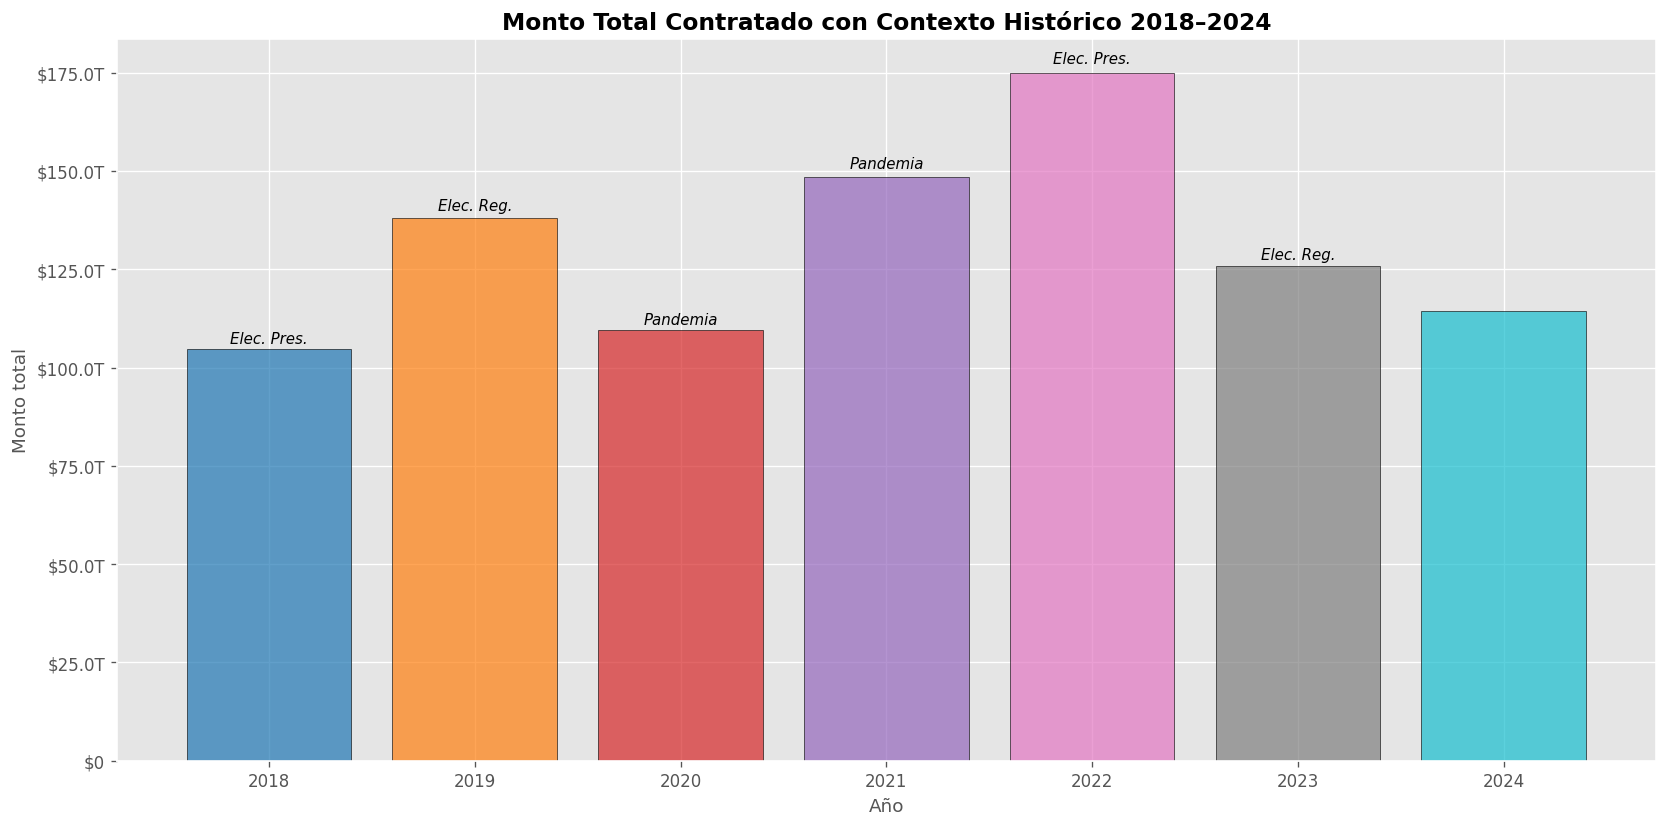


Monto contratado con contexto temporal:


,anio_key,monto_total,num_contratos,es_pandemia,es_elec_pres,es_elec_reg
0,2018,1.047465e+14,1090983.0,False,True,False
1,2019,1.380134e+14,1193513.0,False,False,True
2,2020,1.094466e+14,1134462.0,True,False,False
3,2021,1.485243e+14,1292400.0,True,False,False
4,2022,1.748349e+14,1099821.0,False,True,False
5,2023,1.257925e+14,969726.0,False,False,True
6,2024,1.143712e+14,963955.0,False,False,False


In [16]:
evol_ctx = evol.copy()
flags_tiempo = (df_mun.groupby(COL_AÑO)
                .agg(
                    es_pandemia  = ('es_pandemia',                     'first'),
                    es_elec_pres = ('es_anio_electoral_presidencial',   'first'),
                    es_elec_reg  = ('es_anio_electoral_regional',       'first'),
                ).reset_index())
flags_tiempo[COL_AÑO] = flags_tiempo[COL_AÑO].astype(int)
evol_ctx = evol_ctx.merge(flags_tiempo, on=COL_AÑO, how='left')

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(evol_ctx[COL_AÑO], evol_ctx['monto_total'],
       color=[COLOR_MAP[a] for a in evol_ctx[COL_AÑO]], edgecolor='black', alpha=0.7)
ax.yaxis.set_major_formatter(FuncFormatter(fmt_moneda))
ax.set_title('Monto Total Contratado con Contexto Histórico 2018–2024',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Monto total')

for _, row in evol_ctx.iterrows():
    etiquetas_ctx = []
    if row.get('es_pandemia'):   etiquetas_ctx.append('Pandemia')
    if row.get('es_elec_pres'):  etiquetas_ctx.append('Elec. Pres.')
    if row.get('es_elec_reg'):   etiquetas_ctx.append('Elec. Reg.')
    if etiquetas_ctx:
        ax.text(int(row[COL_AÑO]), row['monto_total'] * 1.015,
                '\n'.join(etiquetas_ctx), ha='center', fontsize=9, style='italic')

plt.tight_layout(); plt.show()

print('\nMonto contratado con contexto temporal:')
display(evol_ctx[[COL_AÑO, 'monto_total', 'num_contratos',
                   'es_pandemia', 'es_elec_pres', 'es_elec_reg']])


## 16. Resumen ejecutivo

In [17]:
print('=' * 70)
print('RESUMEN EJECUTIVO — EDA GOLD MART SECOP-DANE 2018-2024')
print('=' * 70)
print(f'\nPeriodo analizado    : 2018 - 2024')
print(f'Municipios únicos    : {df_mun[COL_DIVIPOLA].nunique():,}')
print(f'Departamentos        : {df_mun[COL_DEPTO].nunique():,}')
print(f'Monto total 2018-24  : {fmt_moneda(df_mun[COL_MONTO].sum())}')
print(f'Contratos totales    : {df_mun[COL_CONTRATOS].sum():,.0f}')
print(f'Proveedores totales  : {df_mun["proveedores_unicos"].sum():,.0f}')

print('\nIndicadores anuales clave:')
resumen_final = evol.set_index(COL_AÑO)[[
    'monto_total', 'num_contratos', 'municipios_activos',
    'monto_promedio', 'var_monto_pct'
]].copy()
resumen_final['monto_total']    = resumen_final['monto_total'].apply(fmt_moneda)
resumen_final['monto_promedio'] = resumen_final['monto_promedio'].apply(fmt_moneda)
resumen_final['num_contratos']  = resumen_final['num_contratos'].apply(lambda x: f'{x:,.0f}')
resumen_final['var_monto_pct']  = resumen_final['var_monto_pct'].apply(
    lambda x: f'{x:+.1f}%' if pd.notna(x) else 'Base')
display(resumen_final)

print('\nGini por año (desigualdad en distribución de contratos):')
for a, g_val in ginis.items():
    if pd.isna(g_val):
        barra = "N/A"
    else:
            barra = '|' * int(g_val * 30)
    print(f'  {a}: {g_val:.3f} [{barra}]')

if 'resumen_cuadrantes' in dir():
    print('\nMunicipios en cuadrante de abandono relativo:')
    for r in resumen_cuadrantes:
        print(f"  {r['año']}: {r['municipios_prioritarios']:,} municipios ({r['pct_sobre_total']}%)")

print('\nFuentes de datos:')
print(f'  Gold Mart   : {MART_PATH.relative_to(ROOT)}')
print(f'  CNPV 2018   : {SPRINT2_PATH.relative_to(ROOT)}')
print(f'  Etnia CNPV  : {ETNIA_PATH.relative_to(ROOT)}')


RESUMEN EJECUTIVO — EDA GOLD MART SECOP-DANE 2018-2024

Periodo analizado    : 2018 - 2024
Municipios únicos    : 1,122
Departamentos        : 33
Monto total 2018-24  : $915.7T
Contratos totales    : 7,744,860
Proveedores totales  : 4,436,961

Indicadores anuales clave:


,monto_total,num_contratos,municipios_activos,monto_promedio,var_monto_pct
anio_key,,,,,
2018,$104.7T,"1,090,983",1122,$93.4B,Base
2019,$138.0T,"1,193,513",1122,$123.0B,+31.8%
2020,$109.4T,"1,134,462",1122,$97.5B,-20.7%
2021,$148.5T,"1,292,400",1122,$132.4B,+35.7%
2022,$174.8T,"1,099,821",1122,$155.8B,+17.7%
2023,$125.8T,"969,726",1122,$112.1B,-28.1%
2024,$114.4T,"963,955",1122,$101.9B,-9.1%



Gini por año (desigualdad en distribución de contratos):
  2018: 0.921 [|||||||||||||||||||||||||||]
  2019: 0.915 [|||||||||||||||||||||||||||]
  2020: 0.929 [|||||||||||||||||||||||||||]
  2021: 0.919 [|||||||||||||||||||||||||||]
  2022: 0.924 [|||||||||||||||||||||||||||]
  2023: 0.891 [||||||||||||||||||||||||||]
  2024: 0.915 [|||||||||||||||||||||||||||]

Municipios en cuadrante de abandono relativo:
  2018: 296 municipios (26.4%)
  2019: 289 municipios (25.8%)
  2020: 281 municipios (25.0%)
  2021: 282 municipios (25.1%)
  2022: 272 municipios (24.2%)
  2023: 275 municipios (24.5%)
  2024: 265 municipios (23.6%)

Fuentes de datos:
  Gold Mart   : datos\oro\marts\latest\mart_desarrollo_social_economico_municipio_anio.parquet
  CNPV 2018   : datos\cruce_secop_dane_sprint2.parquet
  Etnia CNPV  : datos\etnia_checkpoint.parquet
